# IT3301 Applied Machine Learning Assignment
## By: Javian Ng 240592T


As cyber threats continue to grow in frequency and complexity, the need for reliable methods to identify fraudulent and malicious activities rises quickly. In this assignment, I developed machine learning models for XYZ Cybersecurity that can accurately distinguish between legitimate and potentially harmful network activity. I will analyse and prepare the provided dataset, perform suitable feature engineering, compare multiple classification models, evaluate their performance using appropriate metrics, and tune the best-performing model. Alongside building the machine learning models, I also considered ethical issues such as fairness, bias, transparency, and the impact of incorrect predictions to ensure that the final solution is both effective and responsible.

In [ ]:
%pip install optuna imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default="colab" ## if running in vscode change this to pio.renderers.default="vscode", if running in colab dont need to change
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import matthews_corrcoef, classification_report, f1_score, ConfusionMatrixDisplay, fbeta_score, precision_score, recall_score, accuracy_score, confusion_matrix, precision_recall_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import time

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading the dataset

Using pandas, I loaded the three CSVs and used `pd.concat` to combine them into a
single dataframe.

In [3]:
df1 = pd.read_csv('drive/MyDrive/Dataset1.csv')
df2 = pd.read_csv('drive/MyDrive/Dataset2.csv')
df3 = pd.read_csv('drive/MyDrive/Dataset3.csv')

df = pd.concat([df1, df2, df3], axis=0, join='outer', ignore_index=True)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## Data Cleaning

In all the column headers there are extra leading spaces, for example `' Label'`, so I used `.str.strip()` to remove them so the columns can be referenced without the leading space.

Some of the column headers also had mangled label text due to an encoding issue, so I used `.str.replace("�", "-", regex=False)` to replace the mangled symbol with a
dash.

I removed all duplicate rows to avoid data leakage. If one copy of a duplicated row landed in the training set and the other in the test set, the test score would no longer reflect the model's ability to generalise to unseen traffic. Removing exact duplicates before the split is the safe thing to do here.

Some rows had infinite values, which I replaced with NaN and then dropped.

I removed constant columns (columns where every row has the same value) as a form of dimensionality reduction, since they carry no predictive signal and clutter the EDA plots. A few of these also held a constant 0, which could cause zero-division issues if we ever scaled by variance or standard deviation. One caveat worth being honest about: I detect constant columns on the full dataset rather than on the training set only. For genuinely constant columns this is low risk, but strictly speaking it is a decision informed by the whole dataset.


In [4]:
# Keep the original row count for the cleaning summary
raw_rows = len(df)

# Clean up column names (they have extra leading spaces)
df.columns = df.columns.str.strip()

# Fix the mangled label text (encoding issue with the en-dash)
df["Label"] = df["Label"].str.replace("�", "-", regex=False)

# Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
duplicate_rows_removed = before - len(df)
print(f"Removed {duplicate_rows_removed} duplicate rows")

# Replace infinite values with NaN, then drop the small number of rows affected
df = df.replace([np.inf, -np.inf], np.nan)
before = len(df)
df = df.dropna()
invalid_rows_removed = before - len(df)
print(f"Removed {invalid_rows_removed} rows with missing/infinite values")

# Drop columns that never change (zero variance = no predictive value)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Dropping constant columns:", constant_cols)
df = df.drop(columns=constant_cols)

# Drop the duplicated "Fwd Header Length" column if present
if "Fwd Header Length.1" in df.columns:
    df = df.drop(columns=["Fwd Header Length.1"])

# Quick check that everything looks right
print(df.shape)
print(df["Label"].value_counts())
print("Remaining missing values:", df.isna().sum().sum())

Removed 109041 duplicate rows
Removed 509 rows with missing/infinite values
Dropping constant columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
(944552, 68)
Label
BENIGN                        746705
DoS Hulk                      172846
DoS GoldenEye                  10286
DoS slowloris                   5385
DoS Slowhttptest                5228
Bot                             1948
Web Attack - Brute Force        1470
Web Attack - XSS                 652
Web Attack - Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64
Remaining missing values: 0


### Explanatory Data Analysis

Visualisation 1: Bar Chart after cleaning
- This bar chart was used to analyse the impact on the number of rows of data after all the data cleaning steps were done.

Visualisation 2: Class Distribution (Linear Scale)
- This class distribution chart was used to visualise the class imbalance across all the different classes. This class distribution bar plot uses log scale since some of the classes have so little data that it would be difficult to see them on a linear scale bar plot.

Visualisation 3: Spearman Correlation Clustermap
- This visualisation tells us about the spearman correlation for all the features, which allows us to see which features generally are more positively and negatively correlated with each other. Instead of building cluster map on the whole dataset, I subsampled 20,000 rows for building the visualisation, since it is a sufficient sample size to still be representative of the entirety of the dataset, while also cutting down the time needed for running the visualisation cell. The sample was also selected using stratified sampling in order to also take into account class imbalance which is evident in the previous visualisation.

Visualisation 4: Selected Feature Distribution Histogram Plot
- Here, I selected some of the features that showed strong positive correlation with each other to build a histogram plot. Since some of the values from either the `ATTACK` or `BENIGN` class can be very big as compared to the opposing class, I used a `Log` scale to scale it such that we would still be able to see the difference between the 2 classes.

Visualisation 5: Spearman Correlation Heatmap by Traffic Type
- Building on Visualisation 3, I selected a smaller, curated set of network-flow features (duration, byte/packet rates, packet length stats, inter-arrival time) that are commonly informative for intrusion detection, and computed separate Spearman correlation heatmaps for `BENIGN` and `ATTACK` traffic. Splitting by traffic type here (rather than pooling like Visualisation 3) matters because these flow-based features often behave very differently under attack conditions than under normal traffic, so a single pooled correlation matrix would be dominated by the majority `BENIGN` class and could mask attack-specific relationships. Each subplot samples up to 20,000 rows from its respective class and reports the class size in the title for context.

Visualisation 6: Normalised Feature Profile per Attack Class
- To compare how each feature behaves across different attack types (rather than just benign-vs-attack), I took the top 8 most frequent labels in the dataset and computed the mean of each selected feature per class. Since the features are on very different scales (e.g. packet counts vs byte rates vs ports), I z-scored each feature across classes so the heatmap shows relative deviation rather than raw magnitude — this makes it possible to see, for a given feature, which attack classes sit well above or below the average class profile.

Visualisation 7: Mutual Information Between Features and Attack Classes
- This visualisation was built to provide an alternative view to the correlation-based visualisations, I computed mutual information between each feature and a one-vs-rest binary indicator for each of the top 8 attack classes. Unlike Spearman correlation, mutual information can capture non-linear relationships, so this highlights features that may be strongly discriminative for a specific class even if they don't show up as strongly correlated in the earlier heatmaps. A 20,000-row sample (drawn from the top-class subset) was used to keep computation manageable, since mutual information estimation's computation is more expensive than correlation.

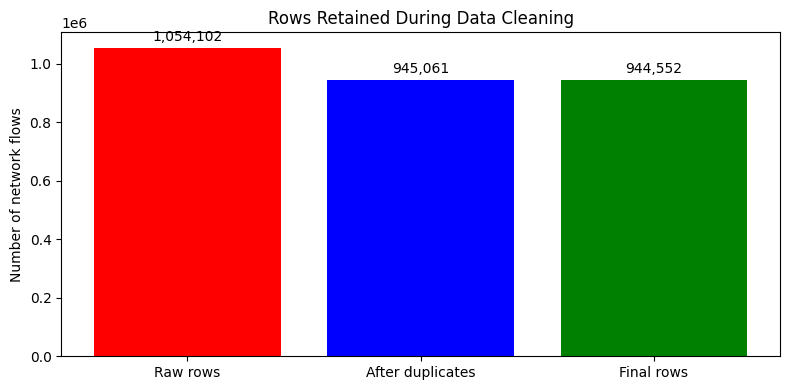

/tmp/ipykernel_9440/467254055.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.values, y=class_counts.index,


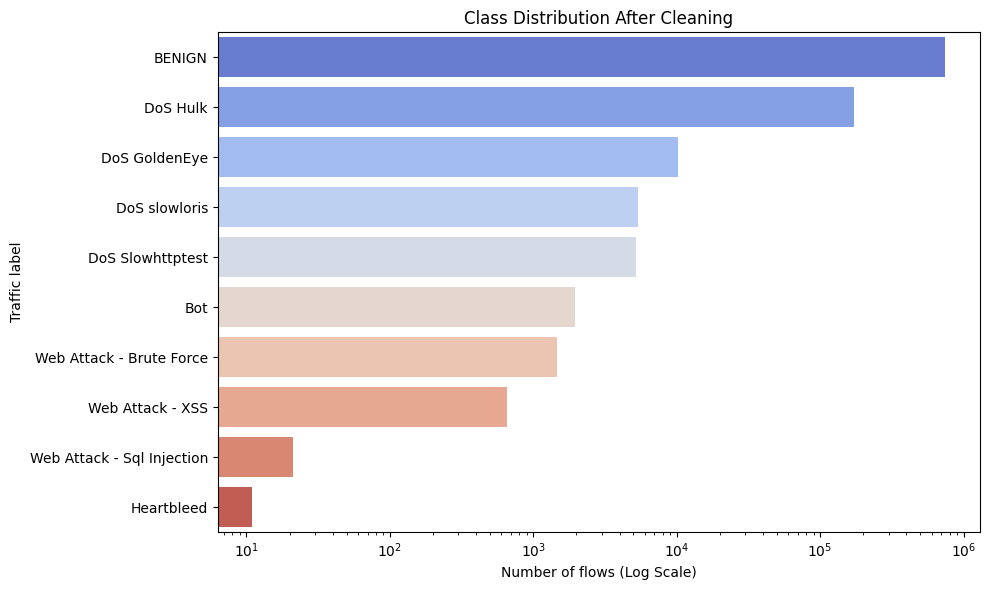

/tmp/ipykernel_9440/467254055.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation_samples = (df.groupby("Label", group_keys=False).apply(lambda x: x.sample(n=min(len(x), int(20_000 * len(x) / len(df))), random_state=42)))


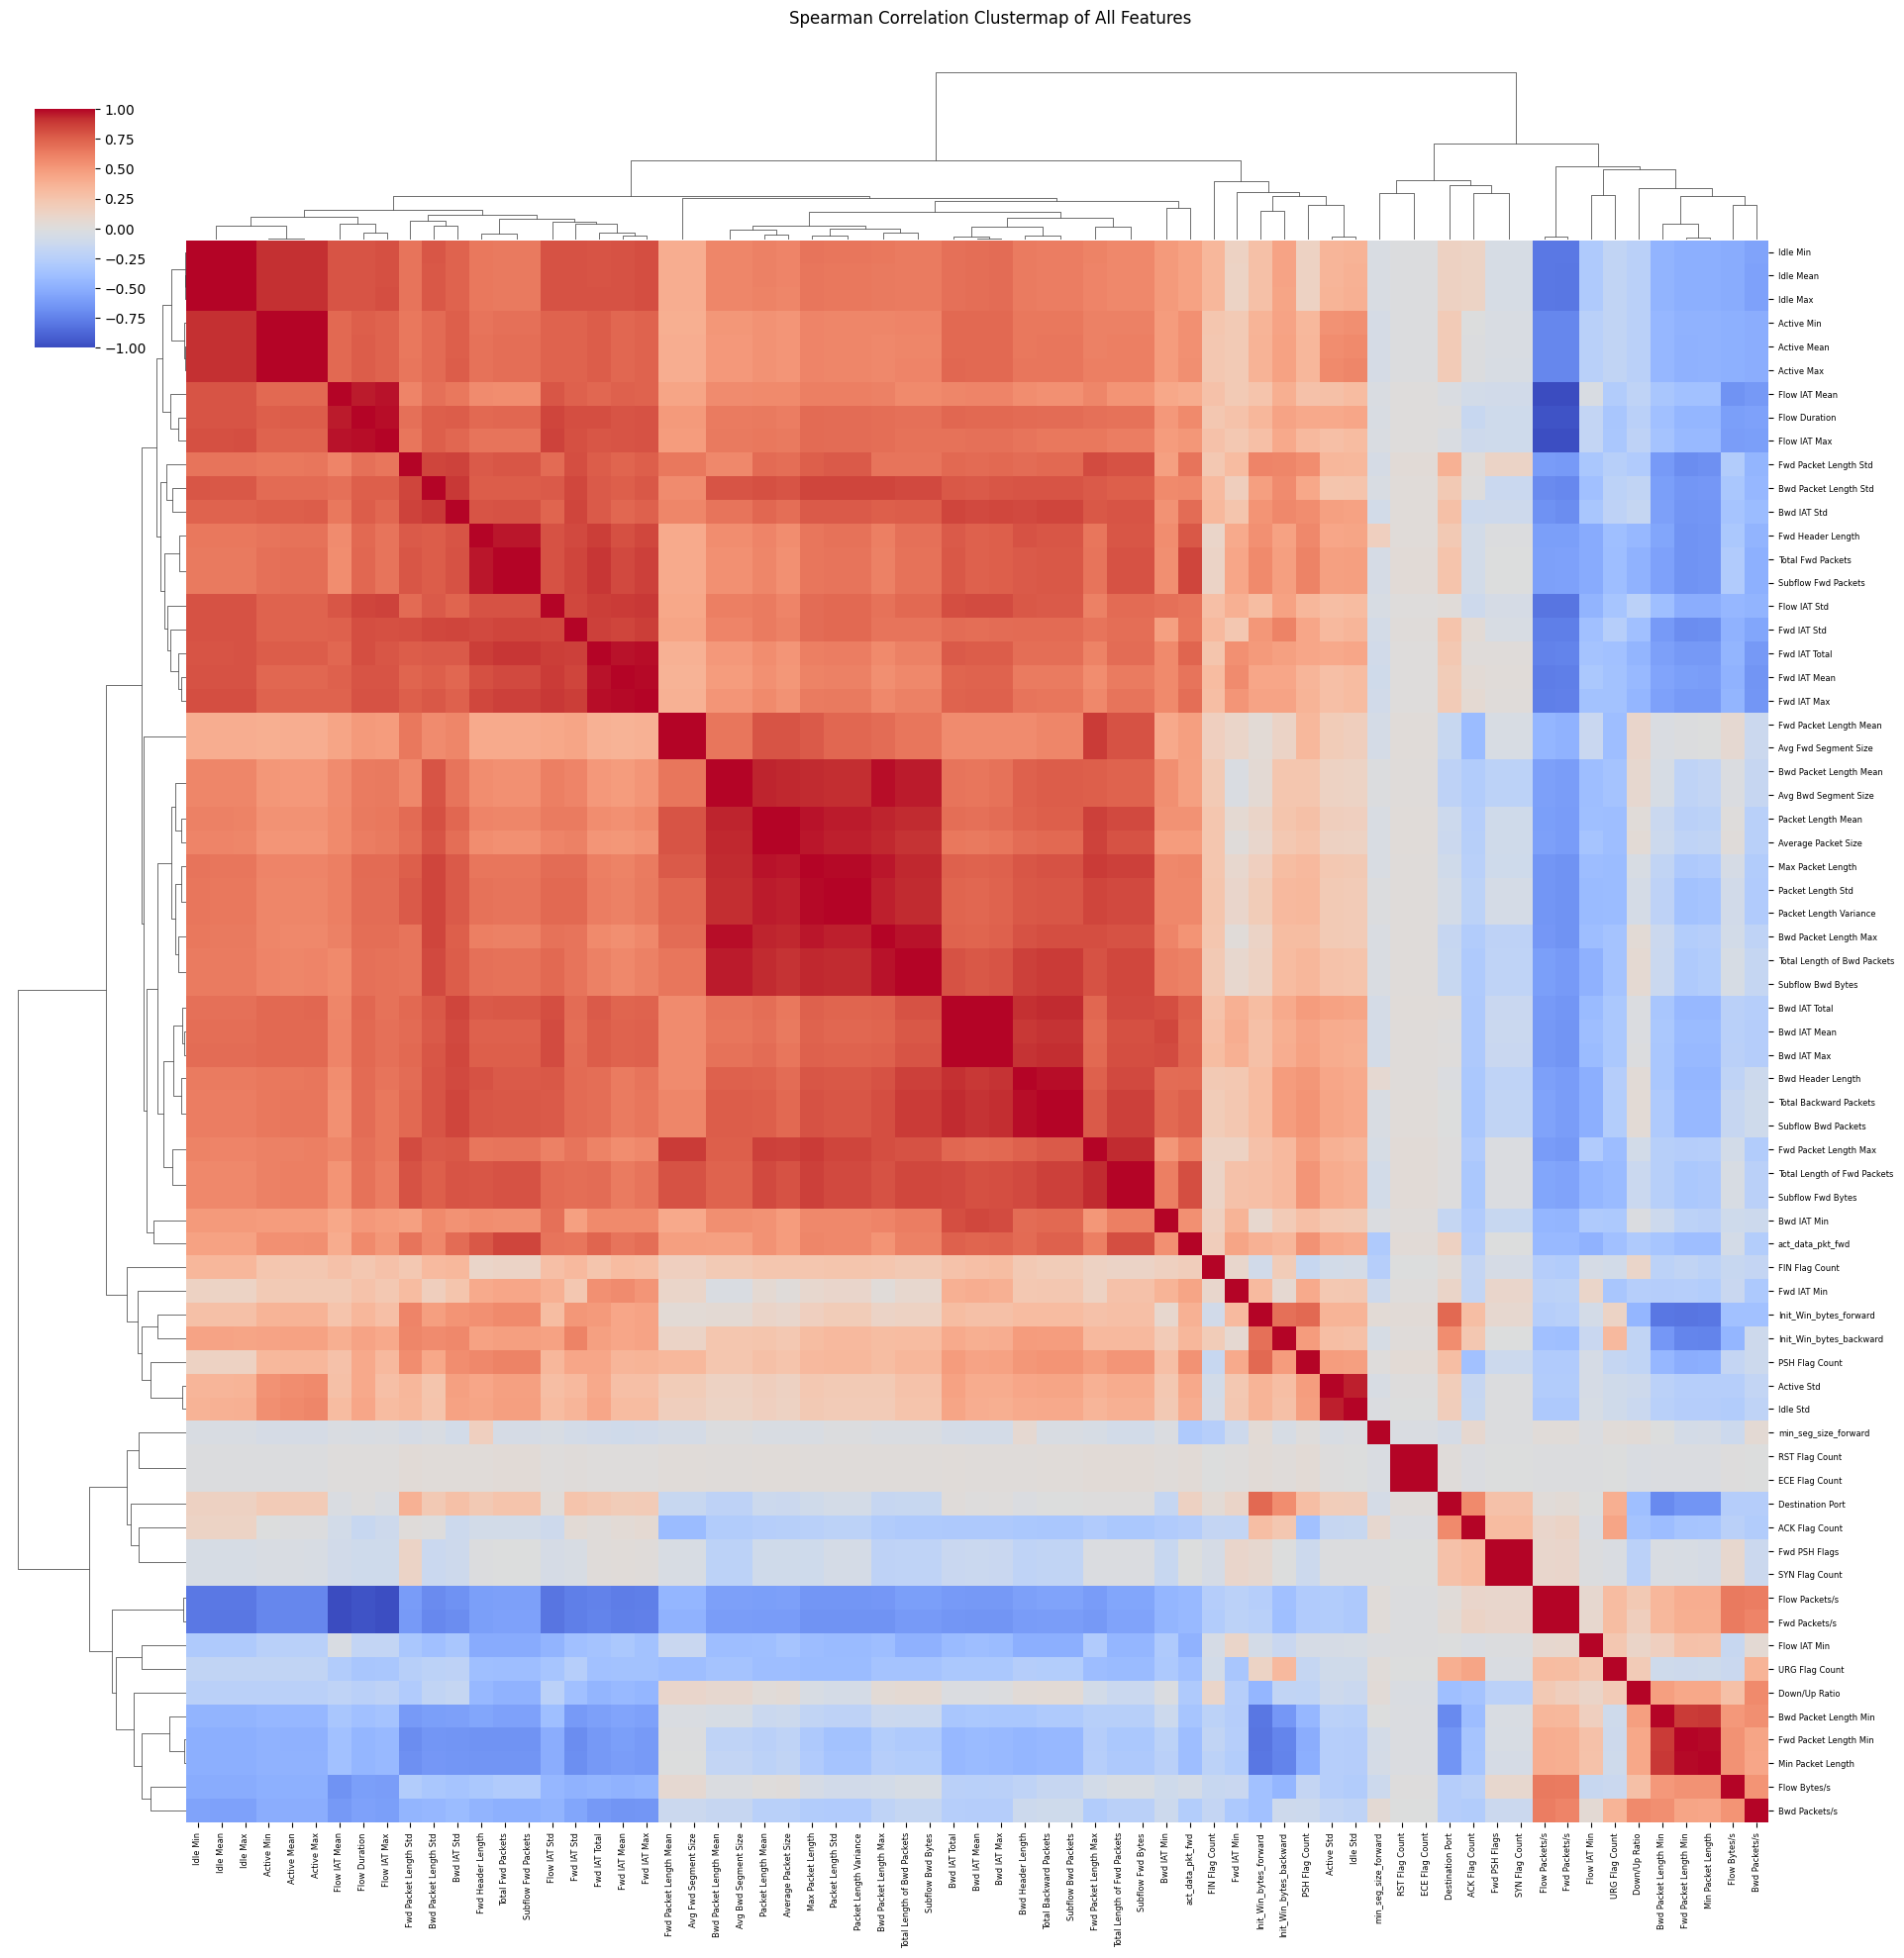

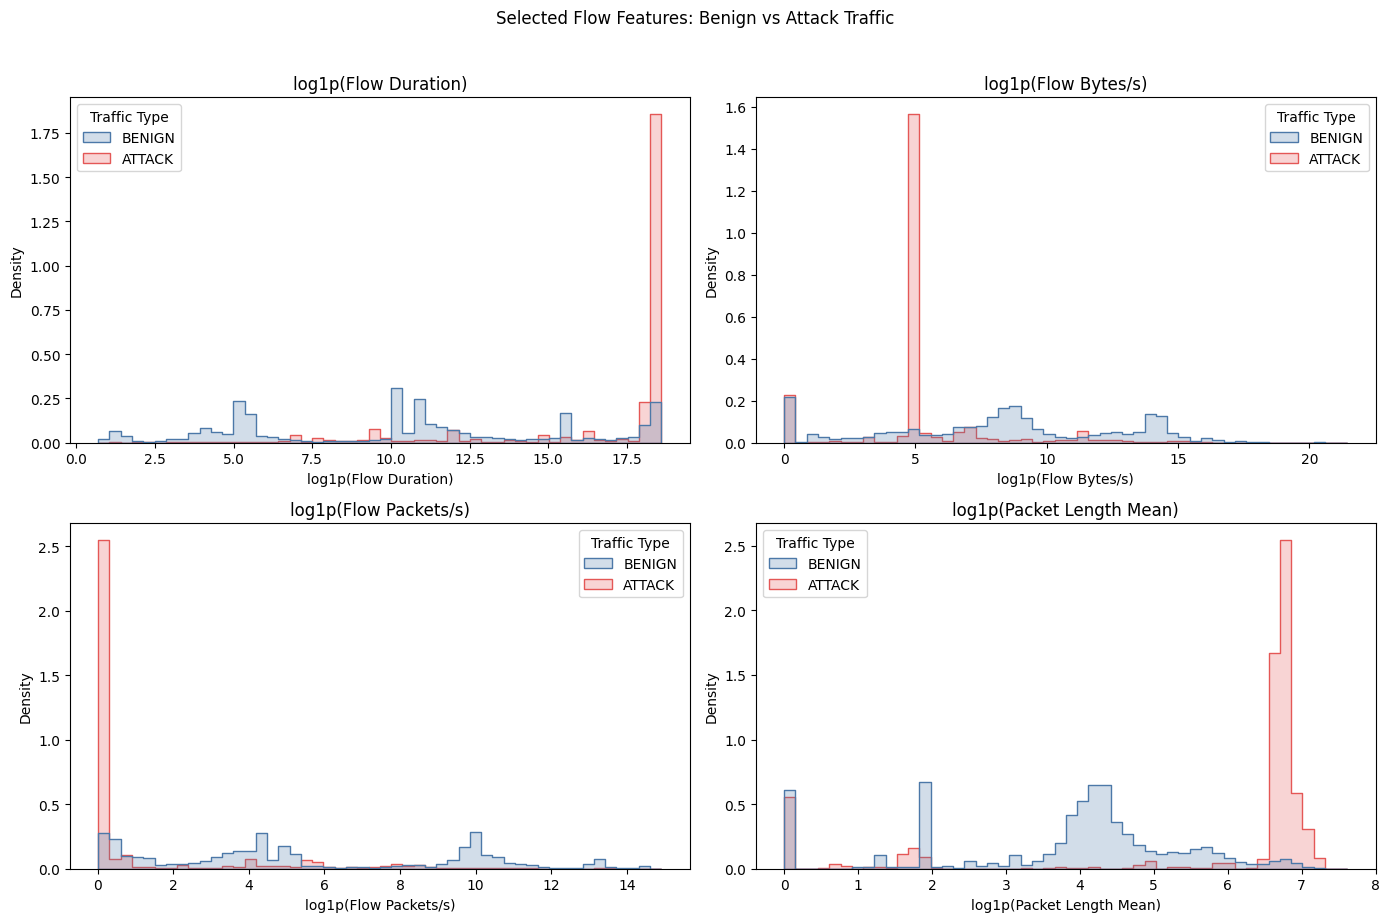

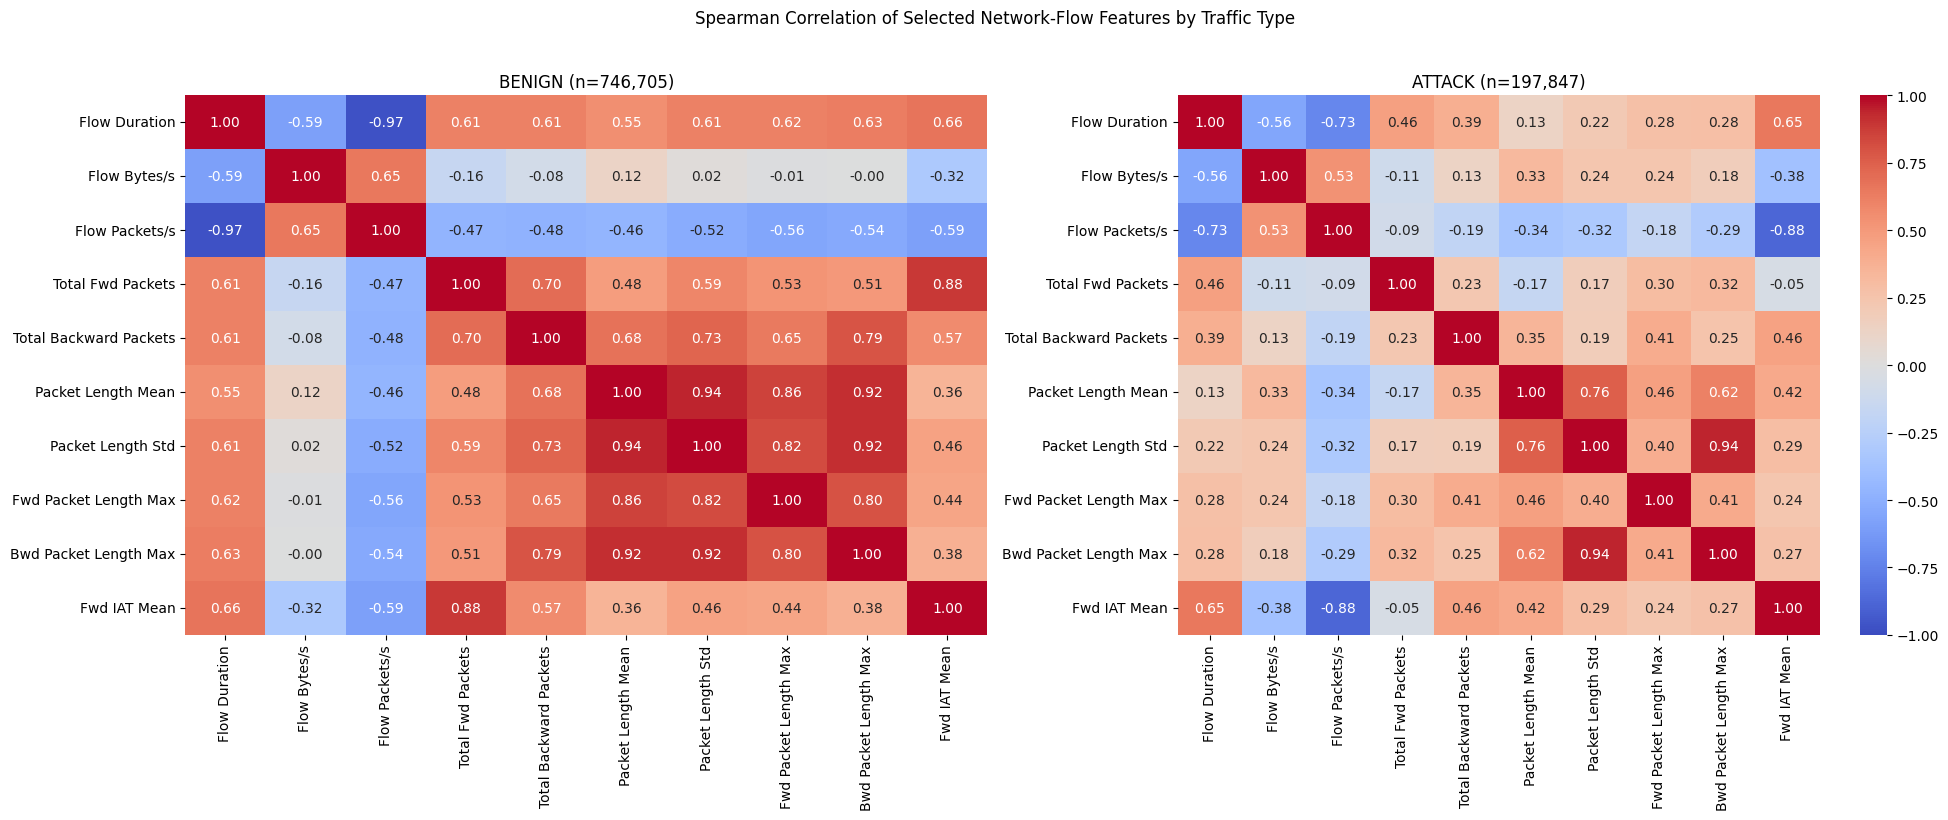

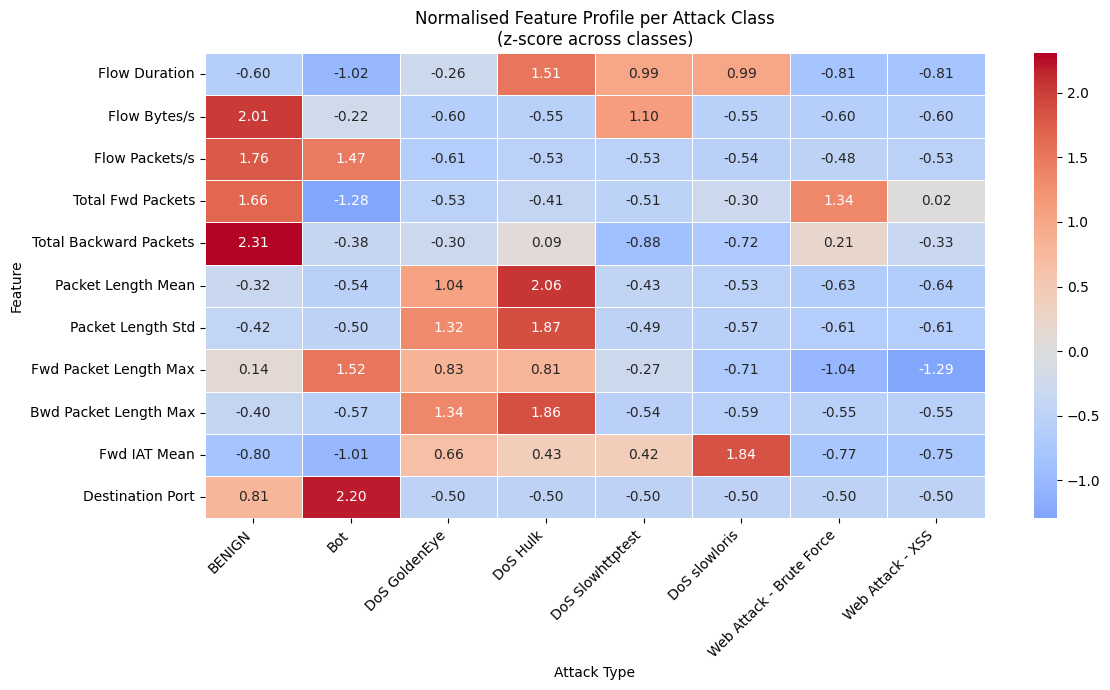

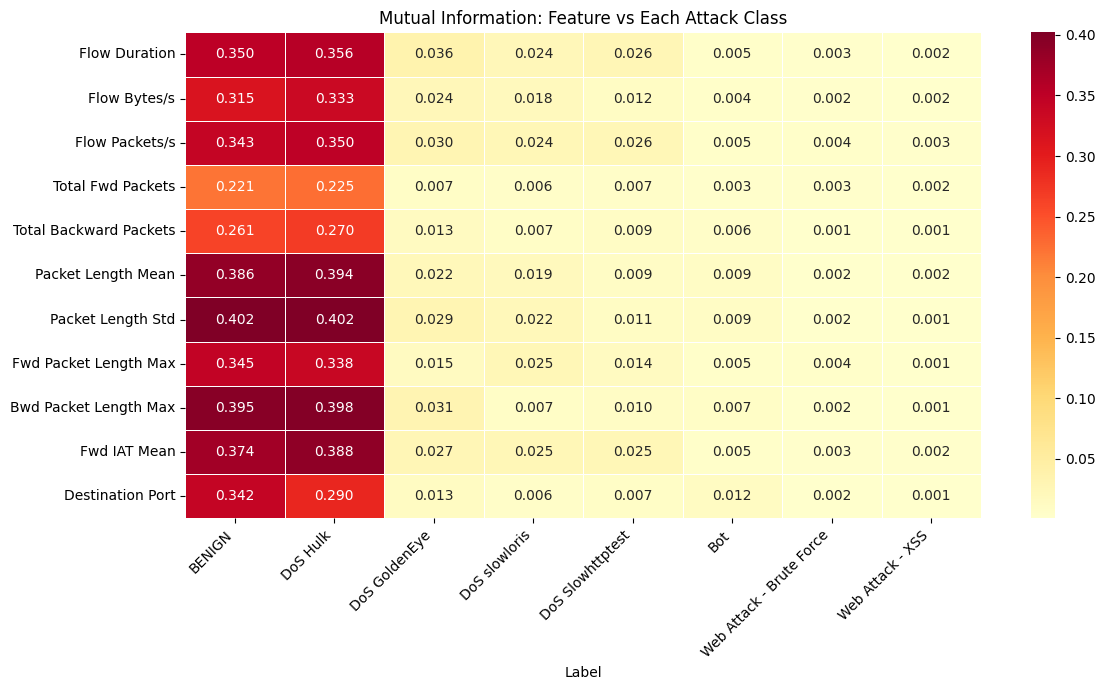

In [5]:
# Visualisation 1: Bar chart after cleaning impact
cleaning_counts = pd.Series({
    "Raw rows": raw_rows,
    "After duplicates": raw_rows - duplicate_rows_removed,
    "Final rows": len(df)
})
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cleaning_counts.index, cleaning_counts.values, color=["red", "blue", "green"])
ax.bar_label(bars, labels=[f"{value:,}" for value in cleaning_counts.values], padding=3)
ax.set_title("Rows Retained During Data Cleaning")
ax.set_ylabel("Number of network flows")
plt.tight_layout()
plt.show()

# Visualisation 2: Class distribution class imbalance after cleaning
class_counts = df["Label"].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=class_counts.values, y=class_counts.index,
            palette="coolwarm", legend=False, ax=ax)
ax.set_xscale("log")
ax.set_title("Class Distribution After Cleaning")
ax.set_xlabel("Number of flows (Log Scale)")
ax.set_ylabel("Traffic label")
plt.tight_layout()
plt.show()

# Visualisation 3: Spearman correlation clustermap for all features
correlation_feature = [feature for feature in df.columns if feature != "Label"]
correlation_samples = (df.groupby("Label", group_keys=False).apply(lambda x: x.sample(n=min(len(x), int(20_000 * len(x) / len(df))), random_state=42)))
correlation_matrix = correlation_samples[correlation_feature].corr(method="spearman")
n = len(correlation_matrix.columns)

g = sns.clustermap(
    correlation_matrix,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    figsize=(max(18, n * 0.3), max(18, n * 0.3)),
    annot=False, linewidths=0, xticklabels=True, yticklabels=True,
    dendrogram_ratio=(0.1, 0.1), cbar_pos=(0.02, 0.85, 0.03, 0.12),
    method="average", metric="euclidean",
)
g.ax_heatmap.tick_params(labelsize=6, rotation=90)
g.ax_heatmap.tick_params(axis="y", rotation=0)
g.fig.suptitle("Spearman Correlation Clustermap of All Features", y=1.02)
plt.show()

# Visualisation 4: selected feature distributions for benign versus attack traffic
selected_features = ["Flow Duration", "Flow Bytes/s", "Flow Packets/s", "Packet Length Mean",]
selected_features = [feature for feature in selected_features if feature in df.columns]
eda_sample = df.sample(n=min(20_000, len(df)), random_state=42).copy()
eda_sample["Traffic Type"] = np.where(eda_sample["Label"] == "BENIGN", "BENIGN", "ATTACK")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, feature in zip(axes.flat, selected_features):
    feature_data = eda_sample[[feature, "Traffic Type"]].copy()
    feature_data["log_value"] = np.log1p(feature_data[feature].clip(lower=0))
    sns.histplot(
        data=feature_data, x="log_value", hue="Traffic Type",
        stat="density", common_norm=False, bins=50, element="step",
        palette={"BENIGN": "#4C78A8", "ATTACK": "#E45756"}, ax=ax,
    )
    ax.set_title(f"log1p({feature})")
    ax.set_xlabel(f"log1p({feature})")

for ax in axes.flat[len(selected_features):]:
    ax.remove()
plt.suptitle("Selected Flow Features: Benign vs Attack Traffic", y=1.02)
plt.tight_layout()
plt.show()

# Visualisation 5: Spearman Correlation of selected features
correlation_features = ["Flow Duration", "Flow Bytes/s", "Flow Packets/s", "Total Fwd Packets",
                        "Total Backward Packets", "Packet Length Mean", "Packet Length Std",
                        "Fwd Packet Length Max", "Bwd Packet Length Max", "Fwd IAT Mean"]

correlation_features = [feature for feature in correlation_features if feature in df.columns]

df_split = df.copy()
df_split["Traffic Type"] = np.where(df_split["Label"] == "BENIGN", "BENIGN", "ATTACK")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, traffic_type in zip(axes, ["BENIGN", "ATTACK"]):
    subset = df_split[df_split["Traffic Type"] == traffic_type][correlation_features]
    sample = subset.sample(n=min(20_000, len(subset)), random_state=42)
    corr = sample.corr(method="spearman")
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f", ax=ax, cbar=ax == axes[-1])
    ax.set_title(f"{traffic_type} (n={len(subset):,})")

plt.suptitle("Spearman Correlation of Selected Network-Flow Features by Traffic Type", y=1.02)
plt.tight_layout()
plt.show()

# Visualisation 6: Mean of each feature per class, then z-score across classes per feature
feature_cols = ["Flow Duration", "Flow Bytes/s", "Flow Packets/s", "Total Fwd Packets",
                "Total Backward Packets", "Packet Length Mean", "Packet Length Std",
                "Fwd Packet Length Max", "Bwd Packet Length Max", "Fwd IAT Mean",
                "Destination Port"]

feature_cols = [c for c in feature_cols if c in df.columns]

top_classes = df["Label"].value_counts().head(8).index
sample = df[df["Label"].isin(top_classes)]

class_profiles = sample.groupby("Label")[feature_cols].mean()
class_profiles_norm = (class_profiles - class_profiles.mean()) / class_profiles.std()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(class_profiles_norm.T, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax)
ax.set_title("Normalised Feature Profile per Attack Class\n(z-score across classes)")
ax.set_xlabel("Attack Type")
ax.set_ylabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Visualisation 7: Mutual information: feature vs each attack class
mi_sample = df[df["Label"].isin(top_classes)].sample(n=min(20_000, len(df)), random_state=42)
mi_matrix = pd.DataFrame(index=feature_cols, columns=top_classes, dtype=float)

for cls in top_classes:
    binary_label = (mi_sample["Label"] == cls).astype(int)
    mi_scores = mutual_info_classif(mi_sample[feature_cols].fillna(0), binary_label, random_state=42)
    mi_matrix[cls] = mi_scores

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(mi_matrix.astype(float), cmap="YlOrRd", annot=True, fmt=".3f",
            linewidths=0.5, ax=ax)
ax.set_title("Mutual Information: Feature vs Each Attack Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

The exploratory data analysis revealed several important characteristics of the dataset. Data cleaning preserved the vast majority of the observations, reducing the dataset from 1,054,102 raw network flows to 944,552 valid records after removing duplicate and invalid entries, indicating that the dataset remained highly representative after preprocessing. The class distribution showed a severe imbalance, with BENIGN and DoS Hulk accounting for most of the observations, while minority attack classes such as Heartbleed and Web Attack–SQL Injection contained only a handful of samples. Correlation analysis using Spearman's rank correlation identified several groups of highly correlated features, particularly among packet length, packet count and forwarding statistics, suggesting the presence of redundant information. However, since the primary classifiers evaluated in this study were tree-based models, which are relatively insensitive to multicollinearity, all features were retained for subsequent modelling.

Feature-level analysis further demonstrated that the selected network-flow attributes contained meaningful information for distinguishing different traffic types. Mutual information analysis identified Packet Length Standard Deviation, Packet Length Mean, Backward Packet Length Maximum, Flow Duration and Flow Packets/s as the most informative features for differentiating common attack categories from benign traffic. The normalised feature profiles showed that each attack class exhibited a distinct combination of feature values, although the minority Web Attack classes displayed similar profiles that could make them more difficult to distinguish. Distribution plots and separate correlation matrices for benign and attack traffic further revealed that malicious traffic alters the relationships between network-flow characteristics, producing patterns that differ substantially from normal traffic. These findings suggest that the selected features provide sufficient discriminatory information for intrusion detection while also explaining why nonlinear ensemble models are better suited to capturing the complex interactions between features than linear models.

## Shared configuration (LightGBM Model)

One place to set the CV scheme and the tuning-subset size, reused by both the binary and multiclass sections.

In [6]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
tuning_size = 200_000

def lgbm_cv_with_smote(trial, X, y, sampling_strategy, class_weight, objective=None):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0)
    }
    fold_scores, best_iterations = [], []
    for fold_index, (train_index, valid_index) in enumerate(cv.split(X, y)):
        X_tr, y_tr = X.iloc[train_index], y.iloc[train_index]
        X_va, y_va = X.iloc[valid_index], y.iloc[valid_index]

        # Resample the training fold only
        X_tr_res, y_tr_res = SMOTE(sampling_strategy=sampling_strategy,
                                   random_state=42).fit_resample(X_tr, y_tr)

        model = LGBMClassifier(**params, objective=objective, class_weight=class_weight,
                               random_state=42, verbosity=-1, n_jobs=-1)
        model.fit(X_tr_res, y_tr_res,
                  eval_set=[(X_va, y_va)],
                  callbacks=[early_stopping(stopping_rounds=50, verbose=False)])

        predictions = model.predict(X_va)
        fold_scores.append(matthews_corrcoef(y_va, predictions))
        best_iterations.append(model.best_iteration_ or params["n_estimators"])
        trial.set_user_attr("best_iterations", list(best_iterations))

        trial.report(float(np.mean(fold_scores)), step=fold_index)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))

### Binary Classification Feature Engineering

The cleaned dataset is split 80/20 with stratification, so every attack class keeps its proportion in both sets. This matters because the data is very imbalanced.

For the binary task (BENIGN vs ATTACK) I handle the imbalance with **SMOTE only** and no class weights. SMOTE oversamples the minority ATTACK class in the training set up to half the size of the BENIGN class (`sampling_strategy=0.5`). I also did not pass `class_weight="balanced"` here, because once SMOTE has rebalanced the classes, adding balanced weights on top would emphasise ATTACK a second time and tends to push BENIGN precision down.

SMOTE is only ever fit on training data. The test set stays as real, imbalanced traffic, so the final numbers reflect reality.

For tuning I draw a 200,000-row stratified subset from the non-SMOTE oversampled training set. SMOTE is then applied inside each CV fold during tuning (see the tuning cell), so no synthetic sample ever leaks from a training fold into a validation fold.

In [7]:
# Binary target
X_binary = df.drop(columns=["Label"])
y_binary = df["Label"].apply(lambda label: "BENIGN" if label == "BENIGN" else "ATTACK")

X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary, y_binary, test_size=0.2, stratify=y_binary, random_state=42)
print(f"Before SMOTE:\n{y_train_binary.value_counts()}\nTotal: {len(y_train_binary)}")

# Full resampled training set (used for baseline + final fits)
binary_smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_binary_resampled, y_train_binary_resampled = binary_smote.fit_resample(
    X_train_binary, y_train_binary)
print(f"\nAfter SMOTE:\n{y_train_binary_resampled.value_counts()}"
      f"\nTotal: {len(y_train_binary_resampled)}")

# Tuning subset drawn from the REAL (pre-SMOTE) training data
X_tune_binary, _, y_tune_binary, _ = train_test_split(
    X_train_binary, y_train_binary, train_size=tuning_size,
    stratify=y_train_binary, random_state=42)
X_tune_binary = X_tune_binary.reset_index(drop=True)
y_tune_binary = y_tune_binary.reset_index(drop=True)

assert len(X_tune_binary) == tuning_size
assert set(y_tune_binary.unique()) == set(y_train_binary.unique())
print("\nTuning subset shape:", X_tune_binary.shape)
print(y_tune_binary.value_counts())


Before SMOTE:
Label
BENIGN    597364
ATTACK    158277
Name: count, dtype: int64
Total: 755641

After SMOTE:
Label
BENIGN    597364
ATTACK    298682
Name: count, dtype: int64
Total: 896046

Tuning subset shape: (200000, 67)
Label
BENIGN    158108
ATTACK     41892
Name: count, dtype: int64


### Binary Classification Baseline Models

Four untuned models to establish a starting point. Logistic Regression is a linear baseline that tells us how far a linear decision boundary gets before reaching for non-linear models. The Decision Tree captures non-linear split rules while staying readable. Random Forest averages many decorrelated trees to cut the single tree's tendency to overfit, especially on the synthetic minority points. LightGBM is sequential gradient boosting, usually the strongest on large tabular data.

All baselines are trained on the SMOTE-resampled training set with default
hyperparameters. Logistic Regression uses `max_iter=1000` so it actually converges, otherwise the before/after comparison later would be measuring convergence rather than tuning.

In [8]:
bin_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=100, tol=1e-3, verbose=1, random_state=42, n_jobs=1))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1, verbose=1),
    "LightGBM": LGBMClassifier(objective="binary", random_state=42, n_jobs=-1, verbosity=1)
}

bin_trained_models = {}
training_times = {}

for name, model in bin_models.items():
    t0 = time.time()
    model.fit(X_train_binary_resampled, y_train_binary_resampled)
    elapsed = time.time() - t0

    bin_trained_models[name] = model
    training_times[name] = elapsed
    print(f"{name}: trained in {elapsed:.1f}s")

print("\nTraining time summary:")
for name, elapsed in sorted(training_times.items(), key=lambda kv: -kv[1]):
    print(f"  {name}: {elapsed:.1f}s")

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.2s finished


Logistic Regression: trained in 8.6s
Decision Tree: trained in 52.6s


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   32.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.5min finished


Random Forest: trained in 89.1s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 597364, number of negative: 298682
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14326
[LightGBM] [Info] Number of data points in the train set: 896046, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.666667 -> initscore=0.693147
[LightGBM] [Info] Start training from score 0.693147
LightGBM: trained in 7.3s

Training time summary:
  Random Forest: 89.1s
  Decision Tree: 52.6s
  Logistic Regression: 8.6s
  LightGBM: 7.3s


### Binary Classification Model Evaluation (Baseline Models)

In [9]:
binary_results = {}
for name, model in bin_trained_models.items():
    preds = model.predict(X_test_binary)
    binary_results[name] = {
        "macro_f1": round(f1_score(y_test_binary, preds, average="macro"), 4),
        "weighted_f1": round(f1_score(y_test_binary, preds, average="weighted"), 4),
        "macro_f2": round(fbeta_score(y_test_binary, preds, beta=2, average="macro", zero_division=0), 4),
        "weighted_f2": round(fbeta_score(y_test_binary, preds, beta=2, average="weighted", zero_division=0), 4),
        "mcc": round(matthews_corrcoef(y_test_binary, preds), 4)
    }
    print(f"{name}")
    print(classification_report(y_test_binary, preds, zero_division=0, digits=4))

binary_results_df = pd.DataFrame(binary_results).T
print(binary_results_df)

Logistic Regression
              precision    recall  f1-score   support

      ATTACK     0.9430    0.9584    0.9506     39570
      BENIGN     0.9889    0.9846    0.9868    149341

    accuracy                         0.9791    188911
   macro avg     0.9659    0.9715    0.9687    188911
weighted avg     0.9793    0.9791    0.9792    188911

Decision Tree
              precision    recall  f1-score   support

      ATTACK     0.9981    0.9993    0.9987     39570
      BENIGN     0.9998    0.9995    0.9997    149341

    accuracy                         0.9995    188911
   macro avg     0.9990    0.9994    0.9992    188911
weighted avg     0.9995    0.9995    0.9995    188911



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.4s finished


Random Forest
              precision    recall  f1-score   support

      ATTACK     0.9980    0.9981    0.9980     39570
      BENIGN     0.9995    0.9995    0.9995    149341

    accuracy                         0.9992    188911
   macro avg     0.9988    0.9988    0.9988    188911
weighted avg     0.9992    0.9992    0.9992    188911

LightGBM
              precision    recall  f1-score   support

      ATTACK     0.9985    0.9997    0.9991     39570
      BENIGN     0.9999    0.9996    0.9998    149341

    accuracy                         0.9996    188911
   macro avg     0.9992    0.9997    0.9994    188911
weighted avg     0.9996    0.9996    0.9996    188911

                     macro_f1  weighted_f1  macro_f2  weighted_f2     mcc
Logistic Regression    0.9687       0.9792    0.9704       0.9792  0.9375
Decision Tree          0.9992       0.9995    0.9993       0.9995  0.9984
Random Forest          0.9988       0.9992    0.9988       0.9992  0.9975
LightGBM               0.99

## Binary Classification Baseline Model Evaluation

All four baseline models performed strongly, but the tree-based models clearly outperformed Logistic Regression. Logistic Regression achieved **97.91% accuracy**, a macro F1-score of **0.9687**, and an MCC of **0.9375**. Its ATTACK precision of **0.9430** indicates that some benign traffic was incorrectly flagged, while its ATTACK recall of **0.9584** means that approximately **4.2% of attacks were missed**. In comparison, Decision Tree, Random Forest, and LightGBM all achieved accuracy above **99.9%**, showing that nonlinear models were better able to capture the complex relationships in the network-flow features.

**LightGBM was the strongest baseline model**, achieving **99.96% accuracy**, a macro F1-score of **0.9994**, a macro F2-score of **0.9996**, and the highest MCC of **0.9989**. Its ATTACK recall of **0.9997** is especially valuable because almost all malicious traffic was detected, while its precision of **0.9985** indicates very few false alarms. However, the near-perfect tree-based results should be interpreted cautiously and validated further through cross-validation, feature inspection, and ideally a time-based or source-based split to confirm that the models generalise to genuinely unseen network traffic.

### Binary Classification Hyperparameter Tuning

Here I performed hyperparameter tuning on all of the models using Optuna. I used `Optuna` here as opposed to `RandomizedSearchCV` and `GridSearchCV`, as `Optuna` uses Bayesian Optimization (TPE) by default, which means that each trial learns from previous results to sample more promising areas for sets of hyperparameters that may be able to achieve lower loss than the previous set of hyperparameters. This means that `Optuna` is able to get more out of fewer trials, which is useful for LightGBM, where parameters like `num_leaves`, `learning_rate`, and `min_child_samples` interact in non-linear ways. MCC was chosen over F1 macro and F1 weighted because it incorporates all four confusion matrix outcomes (including true negatives), giving a more complete and balanced measure of performance on imbalanced binary classification rather than focusing only on positive-class precision and recall. Unlike F1 weighted, which can be dominated by majority-class performance, or F1 macro, which averages per-class scores without accounting for how errors are distributed across the confusion matrix, MCC only produces a high score when the model performs well on both classes, making it a more robust choice for this imbalanced intrusion detection task.

## Binary Classification Logistic Regression Hyperparameter Tuning

In [10]:
def make_progress_callback(model_name):
    def progress_callback(study, trial):
        print(f"[{model_name}] Trial {trial.number} finished in "
              f"{trial.duration.total_seconds():.1f}s | value={trial.value:.4f}")
    return progress_callback

def objective_lr(trial):
    pipe = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=trial.suggest_float("C", 0.01, 100, log=True),
            penalty=trial.suggest_categorical("penalty", ["l2"]),
            max_iter=500, tol=1e-3, verbose=1, random_state=42, n_jobs=1))
    ])
    return cross_val_score(pipe, X_tune_binary, y_tune_binary, cv=cv, scoring="matthews_corrcoef", n_jobs=-1).mean()

study_lr = optuna.create_study(direction="maximize", study_name="Logistic Regression",
                               sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time()
study_lr.optimize(objective_lr, n_trials=20, callbacks=[make_progress_callback("LR")])
lr_time = time.time() - t0


[I 2026-07-24 08:47:09,392] A new study created in memory with name: Logistic Regression
[I 2026-07-24 08:47:19,817] Trial 0 finished with value: 0.9350340816099655 and parameters: {'C': 0.31489116479568624, 'penalty': 'l2'}. Best is trial 0 with value: 0.9350340816099655.


[LR] Trial 0 finished in 10.4s | value=0.9350


[I 2026-07-24 08:47:29,696] Trial 1 finished with value: 0.9359326296922036 and parameters: {'C': 63.512210106407046, 'penalty': 'l2'}. Best is trial 1 with value: 0.9359326296922036.


[LR] Trial 1 finished in 9.9s | value=0.9359


[I 2026-07-24 08:47:39,525] Trial 2 finished with value: 0.9361872056650791 and parameters: {'C': 8.471801418819979, 'penalty': 'l2'}. Best is trial 2 with value: 0.9361872056650791.


...

[LR] Trial 17 finished in 9.0s | value=0.9362


[I 2026-07-24 08:50:00,405] Trial 18 finished with value: 0.9362486194800445 and parameters: {'C': 3.217618717445637, 'penalty': 'l2'}. Best is trial 10 with value: 0.9377960496040353.


[LR] Trial 18 finished in 9.0s | value=0.9362


[I 2026-07-24 08:50:09,218] Trial 19 finished with value: 0.9336572420901877 and parameters: {'C': 0.011290337641647061, 'penalty': 'l2'}. Best is trial 10 with value: 0.9377960496040353.


[LR] Trial 19 finished in 8.8s | value=0.9337


## Binary Classification Decision Tree Hyperparameter Tuning

In [11]:
def objective_dt(trial):
    pipe = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
        ("model", DecisionTreeClassifier(
            max_depth=trial.suggest_categorical("max_depth", [5, 10, 15]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 50),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
            criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
            random_state=42)),
    ])
    return cross_val_score(pipe, X_tune_binary, y_tune_binary, cv=cv,
                           scoring="matthews_corrcoef", n_jobs=-1).mean()

study_dt = optuna.create_study(direction="maximize", study_name="Binary Decision Tree",
                               sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time()
study_dt.optimize(objective_dt, n_trials=20, callbacks=[make_progress_callback("DT")])
dt_time = time.time() - t0

[I 2026-07-24 08:50:09,227] A new study created in memory with name: Binary Decision Tree
[I 2026-07-24 08:50:22,810] Trial 0 finished with value: 0.9830471385392258 and parameters: {'max_depth': 10, 'min_samples_split': 31, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with value: 0.9830471385392258.


[DT] Trial 0 finished in 13.6s | value=0.9830


[I 2026-07-24 08:50:34,303] Trial 1 finished with value: 0.9613732123736921 and parameters: {'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 20, 'criterion': 'gini'}. Best is trial 0 with value: 0.9830471385392258.


[DT] Trial 1 finished in 11.5s | value=0.9614


[I 2026-07-24 08:50:48,067] Trial 2 finished with value: 0.9964995553611132 and parameters: {'max_depth': 15, 'min_samples_split': 27, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 2 with value: 0.9964995553611132.


...

[DT] Trial 17 finished in 15.6s | value=0.9973


[I 2026-07-24 08:54:33,982] Trial 18 finished with value: 0.9968615545472724 and parameters: {'max_depth': 15, 'min_samples_split': 22, 'min_samples_leaf': 5, 'criterion': 'gini'}. Best is trial 17 with value: 0.9973285376895289.


[DT] Trial 18 finished in 15.6s | value=0.9969


[I 2026-07-24 08:54:45,283] Trial 19 finished with value: 0.9615340003695375 and parameters: {'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 6, 'criterion': 'gini'}. Best is trial 17 with value: 0.9973285376895289.


[DT] Trial 19 finished in 11.3s | value=0.9615


## Binary Classification Random Forest Hyperparameter Tuning

In [12]:
def objective_rf(trial):
  pipe = ImbPipeline([
      ("smote", SMOTE(sampling_strategy=0.5, random_state=42)),
      ("model", RandomForestClassifier(
          n_estimators=trial.suggest_int("n_estimators", 100, 600, step=100),
          max_depth=trial.suggest_categorical("max_depth", [10, 15, 20]),
          min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
          min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
          random_state=42, n_jobs=1, verbose=1
      ))
  ])
  return cross_val_score(pipe, X_tune_binary, y_tune_binary, cv=cv, scoring="matthews_corrcoef", n_jobs=-1).mean()

study_rf = optuna.create_study(direction="maximize", study_name="Binary Random Forest",
                               sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time()
study_rf.optimize(objective_rf, n_trials=20, callbacks=[make_progress_callback("RF")])
rf_time = time.time() - t0

[I 2026-07-24 08:54:45,294] A new study created in memory with name: Binary Random Forest
[I 2026-07-24 08:57:30,339] Trial 0 finished with value: 0.9932743770244129 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9932743770244129.


[RF] Trial 0 finished in 165.0s | value=0.9933


[I 2026-07-24 08:58:31,802] Trial 1 finished with value: 0.9927448192457801 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9932743770244129.


[RF] Trial 1 finished in 61.5s | value=0.9927


[I 2026-07-24 09:02:59,448] Trial 2 finished with value: 0.9928061236834775 and parameters: {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.9932743770244129.


...

[RF] Trial 17 finished in 363.6s | value=0.9963


[I 2026-07-24 10:16:32,965] Trial 18 finished with value: 0.9965711123303277 and parameters: {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 18 with value: 0.9965711123303277.


[RF] Trial 18 finished in 311.9s | value=0.9966


[I 2026-07-24 10:21:47,011] Trial 19 finished with value: 0.9965711123303277 and parameters: {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 18 with value: 0.9965711123303277.


[RF] Trial 19 finished in 314.0s | value=0.9966


## Binary Classification LightGBM Hyperparameter Tuning

In [13]:
def objective_lgbm(trial):
    return lgbm_cv_with_smote(trial, X_tune_binary, y_tune_binary, sampling_strategy=0.5, class_weight=None, objective="binary")

study_lgbm = optuna.create_study(
    direction="maximize", study_name="Binary LightGBM",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
t0 = time.time()
study_lgbm.optimize(objective_lgbm, n_trials=20, callbacks=[make_progress_callback("LGBM")])
lgbm_time = time.time() - t0

[I 2026-07-24 10:21:47,029] A new study created in memory with name: Binary LightGBM
[I 2026-07-24 10:22:13,613] Trial 0 finished with value: 0.998822652207863 and parameters: {'n_estimators': 450, 'learning_rate': 0.0862735828664018, 'num_leaves': 97, 'max_depth': 8, 'min_child_samples': 12, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.05808361216819946}. Best is trial 0 with value: 0.998822652207863.


[LGBM] Trial 0 finished in 26.6s | value=0.9988


[I 2026-07-24 10:23:01,720] Trial 1 finished with value: 0.9987925106547527 and parameters: {'n_estimators': 900, 'learning_rate': 0.03027182927734624, 'num_leaves': 95, 'max_depth': 4, 'min_child_samples': 49, 'reg_alpha': 0.8324426408004217, 'reg_lambda': 0.21233911067827616}. Best is trial 0 with value: 0.998822652207863.


[LGBM] Trial 1 finished in 48.1s | value=0.9988


[I 2026-07-24 10:23:27,786] Trial 2 finished with value: 0.9899185839726693 and parameters: {'n_estimators': 250, 'learning_rate': 0.008661333735273127, 'num_leaves': 49, 'max_depth': 7, 'min_child_samples': 24, 'reg_alpha': 0.2912291401980419, 'reg_lambda': 0.6118528947223795}. Best is trial 0 with value: 0.998822652207863.


...

[LGBM] Trial 17 finished in 68.9s | value=0.9989


[I 2026-07-24 10:34:20,932] Trial 18 finished with value: 0.9988527467029392 and parameters: {'n_estimators': 1000, 'learning_rate': 0.060802532575315205, 'num_leaves': 114, 'max_depth': 9, 'min_child_samples': 38, 'reg_alpha': 0.4032396550417173, 'reg_lambda': 0.7758248860496252}. Best is trial 15 with value: 0.9989585037179326.


[LGBM] Trial 18 finished in 44.8s | value=0.9989


[I 2026-07-24 10:34:50,875] Trial 19 pruned. 


[LGBM] Trial 19 finished in 29.9s | value=0.9987


### Binary Classification Model Evaluation (Optuna-tuned Models)

I rebuild each model with its best parameters and fit on the full SMOTE-resampled training set. For LightGBM the tuned `n_estimators` is replaced by the mean early-stopping round found during CV, so the final model uses roughly the number of trees the folds actually settled on.

In [14]:
studies = {"Logistic Regression": study_lr, "Decision Tree": study_dt, "LightGBM": study_lgbm, "Random Forest": study_rf}
study_times = {"Logistic Regression": lr_time, "Decision Tree": dt_time, "LightGBM": lgbm_time, "Random Forest": rf_time}

best_params = {name: study.best_params.copy() for name, study in studies.items()}

print(best_params)


{'Logistic Regression': {'C': 0.796433554014517, 'penalty': 'l2'}, 'Decision Tree': {'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 1, 'criterion': 'gini'}, 'LightGBM': {'n_estimators': 1000, 'learning_rate': 0.022674324132206554, 'num_leaves': 113, 'max_depth': 9, 'min_child_samples': 38, 'reg_alpha': 0.4134140996927128, 'reg_lambda': 0.03623768811989714}, 'Random Forest': {'n_estimators': 500, 'max_depth': 20, 'min_samples_split': 6, 'min_samples_leaf': 2}}


LightGBM final boosting rounds: 700
Logistic Regression: Optuna-tuned binary classifier
              precision    recall  f1-score   support

      BENIGN     0.9889    0.9846    0.9868    149341
      ATTACK     0.9429    0.9584    0.9506     39570

    accuracy                         0.9791    188911
   macro avg     0.9659    0.9715    0.9687    188911
weighted avg     0.9793    0.9791    0.9792    188911

Decision Tree: Optuna-tuned binary classifier
              precision    recall  f1-score   support

      BENIGN     0.9998    0.9994    0.9996    149341
      ATTACK     0.9977    0.9992    0.9984     39570

    accuracy                         0.9993    188911
   macro avg     0.9987    0.9993    0.9990    188911
weighted avg     0.9993    0.9993    0.9993    188911

Random Forest: Optuna-tuned binary classifier
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9994    0.9995    149341
      ATTACK     0.9978    0.9980    0.9979     39570

  

,accuracy,macro_f1,weighted_f1,macro_f2,weighted_f2,attack_recall,attack_f1,attack_f2,matthews_correlation_coefficient
LightGBM,0.9997,0.9995,0.9997,0.9996,0.9997,0.9998,0.9993,0.9996,0.9991
Decision Tree,0.9993,0.9990,0.9993,0.9992,0.9993,0.9992,0.9984,0.9989,0.9980
Random Forest,0.9991,0.9987,0.9991,0.9987,0.9991,0.9980,0.9979,0.9980,0.9974
Logistic Regression,0.9791,0.9687,0.9792,0.9704,0.9792,0.9584,0.9506,0.9553,0.9374



Best binary model: LightGBM
Best test macro-F1: 0.9995


/tmp/ipykernel_9440/1919221252.py:51: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


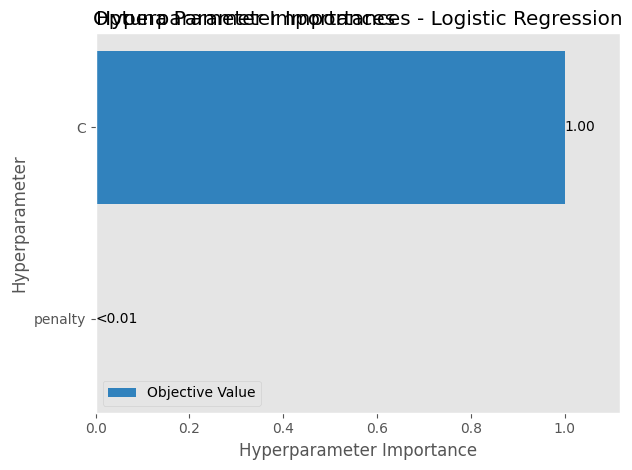

/tmp/ipykernel_9440/1919221252.py:51: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


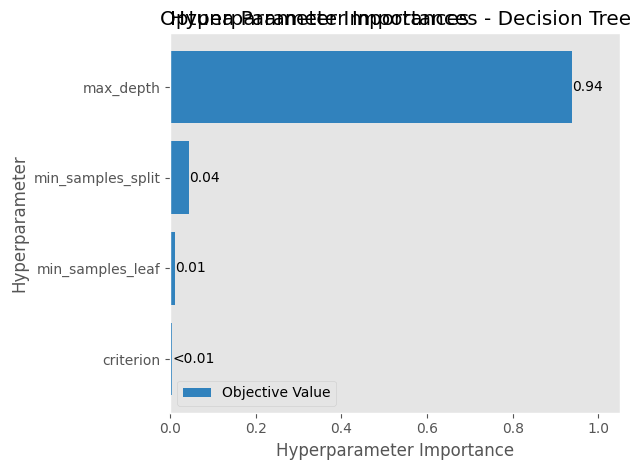

/tmp/ipykernel_9440/1919221252.py:51: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


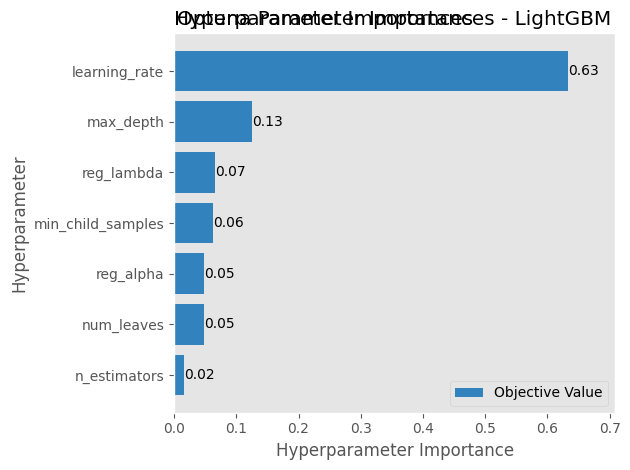

/tmp/ipykernel_9440/1919221252.py:51: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


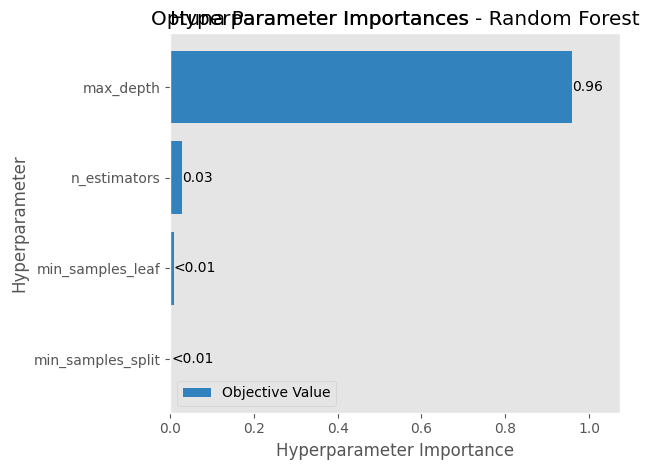

In [15]:
# Use the mean early-stopping round for LightGBM's final n_estimators
best_lgbm_iterations = study_lgbm.best_trial.user_attrs.get("best_iterations", [])
if best_lgbm_iterations:
    best_params["LightGBM"]["n_estimators"] = max(1, int(round(np.mean(best_lgbm_iterations))))
print("LightGBM final boosting rounds:", best_params["LightGBM"]["n_estimators"])

tuned_models_binary = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(**best_params["Logistic Regression"],
                                     max_iter=500, tol=1e-3, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(**best_params["Decision Tree"], random_state=42),
    "Random Forest": RandomForestClassifier(**best_params["Random Forest"], random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(**best_params["LightGBM"], objective="binary", random_state=42, n_jobs=-1)}

for name, model in tuned_models_binary.items():
    model.fit(X_train_binary_resampled, y_train_binary_resampled)

tuned_results_binary = {}
tuned_predictions_binary = {}

for name, model in tuned_models_binary.items():
    predictions = model.predict(X_test_binary)
    tuned_predictions_binary[name] = predictions
    tuned_results_binary[name] = {
        "accuracy": accuracy_score(y_test_binary, predictions),
        "macro_f1": f1_score(y_test_binary, predictions, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test_binary, predictions, average="weighted", zero_division=0),
        "macro_f2": fbeta_score(y_test_binary, predictions, beta=2, average="macro", zero_division=0),
        "weighted_f2": fbeta_score(y_test_binary, predictions, beta=2, average="weighted", zero_division=0),
        "attack_recall": recall_score(y_test_binary, predictions, pos_label="ATTACK", average="binary", zero_division=0),
        "attack_f1": f1_score(y_test_binary, predictions, pos_label="ATTACK", average="binary", zero_division=0),
        "attack_f2": fbeta_score(y_test_binary, predictions, beta=2, pos_label="ATTACK", average="binary", zero_division=0),
        "matthews_correlation_coefficient": matthews_corrcoef(y_test_binary, predictions)
    }
    print(f"{name}: Optuna-tuned binary classifier")
    print(classification_report(y_test_binary, predictions, labels=["BENIGN", "ATTACK"],
                                target_names=["BENIGN", "ATTACK"], zero_division=0, digits=4))

tuned_results_binary_df = pd.DataFrame(tuned_results_binary).T.sort_values(by="macro_f1", ascending=False)
print("\nFinal binary-classification results:")
display(tuned_results_binary_df.round(4))

best_binary_model_name = tuned_results_binary_df["macro_f1"].idxmax()
print(f"\nBest binary model: {best_binary_model_name}")
print("Best test macro-F1:", round(tuned_results_binary_df.loc[best_binary_model_name, "macro_f1"], 4))

for name, study in studies.items():
    try:
        optuna.visualization.matplotlib.plot_param_importances(study)
        plt.title(f"Optuna Parameter Importances - {name}")
        plt.grid(False)
        plt.tight_layout()
        plt.show()
    except (RuntimeError, ValueError):
        print(f"Parameter importance could not be calculated for {name}.")

## Binary Classification Performance Analysis

The binary classification results show that all tree-based models achieved outstanding performance after Optuna hyperparameter optimisation, with LightGBM producing the best overall results. LightGBM achieved the highest accuracy (99.97%), macro F1-score (0.9995), weighted F1-score (0.9997), macro F2-score (0.9996), and Matthews Correlation Coefficient (0.9991), demonstrating excellent discrimination between benign and attack traffic. Decision Tree and Random Forest also performed exceptionally well, both achieving macro F1-scores above 0.998 and attack recall values exceeding 99.8%. In contrast, Logistic Regression achieved comparatively lower performance, with an accuracy of 97.91% and a macro F1-score of 0.9687, indicating that the linear model was less capable of capturing the complex relationships present in the network traffic data.

A comparison of the per-class metrics further highlights the superiority of the tuned LightGBM model. It achieved an attack recall of 99.98%, meaning that almost every malicious network flow was correctly detected, while simultaneously maintaining a precision of 99.87%, resulting in very few false alarms. This produced the highest attack F1-score (0.9993) and attack F2-score (0.9996), demonstrating an excellent balance between precision and recall. The Decision Tree and Random Forest also achieved near-perfect detection performance, although their attack recall and F1-scores were marginally lower. Overall, the results indicate that hyperparameter optimisation enabled LightGBM to become the most effective binary intrusion detection model, providing highly accurate attack detection while maintaining excellent classification performance for benign traffic.

## Reusable T-SNE function for Binary Classification and Multiclass Classification

In [42]:
def build_tsne_dataframe(X, y_true, y_pred, max_per_class=1000, perplexity=30, n_components=2, random_state=42 ):

    X_reset = X.reset_index(drop=True)
    y_true_reset = pd.Series(np.asarray(y_true), name="Actual").reset_index(drop=True)
    y_pred_reset = pd.Series(np.asarray(y_pred), name="Predicted").reset_index(drop=True)

    if not (len(X_reset) == len(y_true_reset) == len(y_pred_reset)):
        raise ValueError("X, y_true and y_pred must contain the same number of rows.")

    rng = np.random.RandomState(random_state)
    selected_positions = []

    for label in y_true_reset.unique():

        class_positions = np.flatnonzero(y_true_reset.to_numpy() == label)
        sample_size = min(max_per_class, len(class_positions))
        sampled_positions = rng.choice(class_positions, size=sample_size, replace=False)
        selected_positions.extend(sampled_positions)

    selected_positions = np.asarray(selected_positions, dtype=int)
    rng.shuffle(selected_positions)
    X_sample = X_reset.iloc[selected_positions].copy()
    tsne_df = pd.DataFrame({"Actual": y_true_reset.iloc[selected_positions].to_numpy(), "Predicted": y_pred_reset.iloc[selected_positions].to_numpy()})
    tsne_df["Evaluation"] = np.where(tsne_df["Actual"] == tsne_df["Predicted"], "Correct", "Misclassified")
    X_scaled = StandardScaler().fit_transform(X_sample)
    pca_components = min(50, X_scaled.shape[1], X_scaled.shape[0] - 1)

    if X_scaled.shape[1] > pca_components:
        X_reduced = PCA(n_components=pca_components, random_state=random_state).fit_transform(X_scaled)
    else:
        X_reduced = X_scaled

    if len(X_reduced) <= perplexity:
        effective_perplexity = max(2, len(X_reduced) - 1)
    else:
        effective_perplexity = perplexity

    print("t-SNE sample size:", len(X_reduced))
    print("PCA dimensions:", X_reduced.shape[1])
    print("Perplexity:", effective_perplexity)
    print("\nSampled class distribution:")
    print(tsne_df["Actual"].value_counts())

    embedding = TSNE(n_components=n_components, perplexity=effective_perplexity, init="pca",
                     learning_rate="auto", max_iter=1000, random_state=random_state, method="barnes_hut",
                     verbose=1).fit_transform(X_reduced)

    for dimension in range(n_components):
        tsne_df[f"TSNE{dimension + 1}"] = embedding[:, dimension]

    return tsne_df

## Interactive Binary Classification t-SNE Plot

In [43]:
best_binary_predictions = tuned_predictions_binary[best_binary_model_name]

binary_tsne_df = build_tsne_dataframe(X=X_test_binary, y_true=y_test_binary, y_pred=best_binary_predictions,
                                      max_per_class=2500, perplexity=30, n_components=3, random_state=42)

conditions = [((binary_tsne_df["Actual"] == "BENIGN") & (binary_tsne_df["Predicted"] == "BENIGN")),
              ((binary_tsne_df["Actual"] == "BENIGN") & (binary_tsne_df["Predicted"] == "ATTACK")),
              ((binary_tsne_df["Actual"] == "ATTACK") & (binary_tsne_df["Predicted"] == "BENIGN")),
              ((binary_tsne_df["Actual"] == "ATTACK") & (binary_tsne_df["Predicted"] == "ATTACK"))]

outcomes = ["Correct BENIGN", "False alarm (FP)",
            "Missed ATTACK (FN)", "Correct ATTACK"]

binary_tsne_df["Prediction outcome"] = np.select(conditions, outcomes, default="Unknown")

fig_actual = px.scatter_3d(binary_tsne_df, x="TSNE1", y="TSNE2", z="TSNE3",
                           color="Actual", title="Binary 3D t-SNE — Actual Classes", opacity=0.65,
                           hover_data={"Actual": True, "Predicted": True, "Prediction outcome": True,
                                        "TSNE1": ":.2f", "TSNE2": ":.2f", "TSNE3": ":.2f"})

fig_actual.update_traces(marker=dict(size=3, line=dict(width=0)))

fig_actual.update_layout(width=1000, height=800,
                         legend_title_text="Actual class",
    scene=dict(xaxis_title="t-SNE dimension 1",
               yaxis_title="t-SNE dimension 2",
               zaxis_title="t-SNE dimension 3"))

fig_actual.show()

fig_outcome = px.scatter_3d(
    binary_tsne_df, x="TSNE1", y="TSNE2", z="TSNE3",
    color="Prediction outcome", title=f"Binary 3D t-SNE — Prediction Outcomes<br>{best_binary_model_name}",
    opacity=0.70,
    hover_data={"Actual": True, "Predicted": True, "Prediction outcome": True,
                "TSNE1": ":.2f", "TSNE2": ":.2f", "TSNE3": ":.2f"},
    color_discrete_map={"Correct BENIGN": "blue", "False alarm (FP)": "orange",
                        "Missed ATTACK (FN)": "red", "Correct ATTACK": "green",
                        "Unknown": "gray"})

fig_outcome.update_traces(marker=dict(size=3, line=dict(width=0)))

fig_outcome.update_layout(
    width=1000,
    height=800,
    legend_title_text="Prediction outcome",
    scene=dict(xaxis_title="t-SNE dimension 1", yaxis_title="t-SNE dimension 2", zaxis_title="t-SNE dimension 3"))

fig_outcome.show()

t-SNE sample size: 5000
PCA dimensions: 50
Perplexity: 30

Sampled class distribution:
Actual
ATTACK    2500
BENIGN    2500
Name: count, dtype: int64
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 5000 samples in 0.001s...
[t-SNE] Computed neighbors for 5000 samples in 0.204s...
[t-SNE] Computed conditional probabilities for sample 1000 / 5000
[t-SNE] Computed conditional probabilities for sample 2000 / 5000
[t-SNE] Computed conditional probabilities for sample 3000 / 5000
[t-SNE] Computed conditional probabilities for sample 4000 / 5000
[t-SNE] Computed conditional probabilities for sample 5000 / 5000
[t-SNE] Mean sigma: 0.016995
[t-SNE] KL divergence after 250 iterations with early exaggeration: 57.711472
[t-SNE] KL divergence after 1000 iterations: 0.342048


## Binary 3D t-SNE Visualisation Analysis

The binary 3D t-SNE visualisation shows that the network traffic can be broadly separated into the BENIGN and ATTACK classes, although some overlap exists between the two groups. Several dense clusters are predominantly composed of either benign or attack samples, indicating that the extracted features capture meaningful differences between normal and malicious network traffic. However, the presence of overlapping regions suggests that certain attack samples share similar feature characteristics with benign traffic, making perfect linear separation difficult. This observation is expected for real-world intrusion detection datasets, where some attack behaviours closely resemble legitimate network activity.

The prediction outcome visualisation demonstrates that the tuned LightGBM model correctly classified the overwhelming majority of samples, with most benign and attack instances appearing as correctly classified points. Only a small number of missed attacks (false negatives) are visible, and these are concentrated near the boundaries where benign and attack clusters overlap. Notably, no false alarm (false positive) points are observed, indicating that the model achieved perfect precision for the ATTACK class on the sampled data while maintaining a very low false negative rate. These findings are consistent with the excellent quantitative performance obtained during evaluation, confirming that the tuned LightGBM model effectively distinguishes between benign and malicious traffic while limiting classification errors to ambiguous regions of the feature space.

### Binary Classification Model Comparison: Baseline VS Optuna-tuned

In [18]:
comparison = pd.concat([binary_results_df.add_suffix(" (before)"), tuned_results_binary_df.add_suffix(" (after tuning)")], axis=1)
print(comparison)

                     macro_f1 (before)  weighted_f1 (before)  \
Logistic Regression             0.9687                0.9792   
Decision Tree                   0.9992                0.9995   
Random Forest                   0.9988                0.9992   
LightGBM                        0.9994                0.9996   

                     macro_f2 (before)  weighted_f2 (before)  mcc (before)  \
Logistic Regression             0.9704                0.9792        0.9375   
Decision Tree                   0.9993                0.9995        0.9984   
Random Forest                   0.9988                0.9992        0.9975   
LightGBM                        0.9996                0.9996        0.9989   

                     accuracy (after tuning)  macro_f1 (after tuning)  \
Logistic Regression                 0.979138                 0.968693   
Decision Tree                       0.999344                 0.999010   
Random Forest                       0.999132                 0.998689

## Binary Classification: Baseline vs Tuned Models

Hyperparameter tuning produced only small changes because the baseline tree-based models were already performing near their maximum. Logistic Regression remained almost unchanged, with macro F1 decreasing slightly from **0.9687** to **0.9687** and MCC from **0.9375** to **0.9374**, showing that tuning could not overcome the limitations of its linear decision boundary. Decision Tree and Random Forest also experienced minor reductions in macro F1 and MCC, suggesting that their default configurations were already highly effective and that the tuned parameters may have introduced slightly more regularisation.

LightGBM benefited the most from tuning and remained the strongest binary classifier. Its macro F1 increased from **0.9994** to **0.9995**, while its MCC improved from **0.9989** to **0.9991**. It also achieved the highest ATTACK recall of **0.9998**, ATTACK F1-score of **0.9993**, and ATTACK F2-score of **0.9996**, indicating that it detected almost every attack while maintaining very few false alarms. Overall, the tuned LightGBM model provided the best balance between majority- and minority-class performance and was therefore selected as the final binary classification model.

## Multiclass Classification Feature Engineering

Same 80/20 stratified split, this time keeping the full attack labels.

The imbalance handling is layered on purpose, and this is where the design differs from
the binary task:

- **SMOTE** oversamples the three mid-sized minority classes that have enough real
  examples to synthesise from reliably: Bot to 6,000, Web Attack - Brute Force to 4,500,
  and Web Attack - XSS to 2,000. The ultra-rare classes (SQL Injection, Heartbleed) are
  left alone because building synthetic points from only a handful of originals is
  unreliable.
- **Class weights** then handle the classes SMOTE did not touch. I compute balanced
  weights from the real training distribution, but I reset the three SMOTE-boosted
  classes to the majority weight. That way SMOTE handles those three and the weights
  handle the rest, and no class is corrected for twice.

For tuning I again draw a 200,000-row subset from the real training data, keeping every
row of the ultra-rare classes so the folds still see them. SMOTE is applied inside each
fold. To keep the synthetic ratio sensible on the smaller tuning subset (the fixed 6,000
style targets would blow up a class that only has a couple hundred rows in the subset), I
oversample the three target classes proportionally within each fold via a callable
strategy.

In [19]:
X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(y_train.value_counts())

smote_target_classes = ["Bot", "Web Attack - Brute Force", "Web Attack - XSS"]

final_sampling_strategy = {"Bot": 6000, "Web Attack - Brute Force": 4500, "Web Attack - XSS": 2000}
final_sampling_strategy = {c: n for c, n in final_sampling_strategy.items()
                           if c in y_train.unique()}

smote = SMOTE(sampling_strategy=final_sampling_strategy, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

class_labels = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=class_labels, y=y_train)
class_weight_dict = dict(zip(class_labels, weights))

majority_weight = min(class_weight_dict.values())
for c in smote_target_classes:
    if c in class_weight_dict:
        class_weight_dict[c] = majority_weight

print("\nClass weights (SMOTE-boosted classes set to majority weight):")
for c, w in sorted(class_weight_dict.items(), key=lambda kv: -kv[1]):
    print(f"  {c}: {w:.3f}")

real_counts = y_train.value_counts()
rare_classes = real_counts[real_counts < 100].index
rare_mask = y_train.isin(rare_classes)

X_tune_rare, y_tune_rare = X_train.loc[rare_mask], y_train.loc[rare_mask]
X_common_pool, y_common_pool = X_train.loc[~rare_mask], y_train.loc[~rare_mask]
common_tuning_size = tuning_size - len(y_tune_rare)

X_tune_common, _, y_tune_common, _ = train_test_split(
    X_common_pool, y_common_pool, train_size=common_tuning_size,
    stratify=y_common_pool, random_state=42)

X_tune = pd.concat([X_tune_rare, X_tune_common], ignore_index=True)
y_tune = pd.concat([y_tune_rare, y_tune_common], ignore_index=True)
shuffle_order = np.random.RandomState(42).permutation(len(X_tune))
X_tune = X_tune.iloc[shuffle_order].reset_index(drop=True)
y_tune = y_tune.iloc[shuffle_order].reset_index(drop=True)

assert len(X_tune) == tuning_size
assert set(y_tune.unique()) == set(y_train.unique())
print("Tuning subset shape:", X_tune.shape)
print(y_tune.value_counts())


def tuning_oversampler(y_fold):
    counts = pd.Series(y_fold).value_counts()
    targets = {}
    for c in smote_target_classes:
        if c in counts and counts[c] >= 6:
            targets[c] = min(int(counts[c] * 3), 6000)
    return targets

Label
BENIGN                        597363
DoS Hulk                      138277
DoS GoldenEye                   8229
DoS slowloris                   4308
DoS Slowhttptest                4182
Bot                             1558
Web Attack - Brute Force        1176
Web Attack - XSS                 522
Web Attack - Sql Injection        17
Heartbleed                         9
Name: count, dtype: int64

Class weights (SMOTE-boosted classes set to majority weight):
  Heartbleed: 8396.011
  Web Attack - Sql Injection: 4444.947
  DoS Slowhttptest: 18.069
  DoS slowloris: 17.540
  DoS GoldenEye: 9.183
  DoS Hulk: 0.546
  BENIGN: 0.126
  Bot: 0.126
  Web Attack - Brute Force: 0.126
  Web Attack - XSS: 0.126
Tuning subset shape: (200000, 67)
Label
BENIGN                        158093
DoS Hulk                       36595
DoS GoldenEye                   2178
DoS slowloris                   1140
DoS Slowhttptest                1107
Bot                              412
Web Attack - Brute Force      

### Multiclass Classification Baseline Models


Four untuned models to establish a starting point. Logistic Regression is a linear baseline that tells us how far a linear decision boundary gets before reaching for non-linear models. The Decision Tree captures non-linear split rules while staying readable. Random Forest averages many decorrelated trees to cut the single tree's tendency to overfit, especially on the synthetic minority points. LightGBM is sequential gradient boosting, usually the strongest on large tabular data.

All baselines are trained on the SMOTE-resampled training set with default
hyperparameters. Logistic Regression uses `max_iter=1000` so it actually converges, otherwise the before/after comparison later would be measuring convergence rather than tuning.




In [20]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight=class_weight_dict, verbose=1, random_state=42, n_jobs=1))
    ]),
    "Decision Tree": DecisionTreeClassifier(class_weight=class_weight_dict, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight=class_weight_dict, random_state=42, verbose=1, n_jobs=-1),
    "LightGBM": LGBMClassifier(class_weight=class_weight_dict, random_state=42, n_jobs=-1, verbosity=1)
}

trained_models = {}
training_times = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    elapsed = time.time() - t0

    trained_models[name] = model
    training_times[name] = elapsed
    print(f"{name}: trained in {elapsed:.1f}s")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   56.4s finished


Logistic Regression: trained in 59.1s
Decision Tree: trained in 63.0s


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   30.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.3min finished


Random Forest: trained in 82.2s
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.068070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14300
[LightGBM] [Info] Number of data points in the train set: 764885, number of used features: 67
[LightGBM] [Info] Start training from score -1.948895
[LightGBM] [Info] Start training from score -6.549660
[LightGBM] [Info] Start training from score -1.948895
[LightGBM] [Info] Start training from score -1.948895
[LightGBM] [Info] Start training from score -1.948895
[LightGBM] [Info] Start training from score -1.948895
[LightGBM] [Info] Start training from score -1.948895
[LightGBM] [Info] Start training from score -6.837343
[LightGBM] [Info] Start training from score -1.948895
[LightGBM] [Info] Start training from score -7.

### Multiclass Classification Model Evaluation (Baseline Models)

In [21]:
results = {}
for name, model in trained_models.items():
    preds = model.predict(X_test)
    results[name] = {
        "macro_f1": round(f1_score(y_test, preds, average="macro"), 4),
        "weighted_f1": round(f1_score(y_test, preds, average="weighted"), 4),
        "macro_f2": round(fbeta_score(y_test, preds, beta=2, average="macro", zero_division=0), 4),
        "weighted_f2": round(fbeta_score(y_test, preds, beta=2, average="weighted", zero_division=0), 4),
        "matthews_correlation_coefficient": round(matthews_corrcoef(y_test, preds), 4),
        "train_time_s": round(training_times[name], 1)
    }
    print(f"{name}")
    print(classification_report(y_test, preds, zero_division=0, digits=4))

results_df = pd.DataFrame(results).T
print(results_df)

print("\nTraining time:")
for name, elapsed in sorted(training_times.items(), key=lambda kv: -kv[1]):
    print(f"  {name}: {elapsed:.1f}s")

Logistic Regression
                            precision    recall  f1-score   support

                    BENIGN     0.9980    0.9437    0.9701    149342
                       Bot     0.3064    0.3692    0.3349       390
             DoS GoldenEye     0.7331    0.9708    0.8354      2057
                  DoS Hulk     0.9453    0.9981    0.9710     34569
          DoS Slowhttptest     0.4821    0.9895    0.6483      1046
             DoS slowloris     0.4208    0.9666    0.5863      1077
                Heartbleed     0.5000    1.0000    0.6667         2
  Web Attack - Brute Force     0.2678    0.8810    0.4108       294
Web Attack - Sql Injection     0.0017    1.0000    0.0033         4
          Web Attack - XSS     0.0000    0.0000    0.0000       130

                  accuracy                         0.9524    188911
                 macro avg     0.4655    0.8119    0.5427    188911
              weighted avg     0.9761    0.9524    0.9620    188911

Decision Tree
           

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.6s finished


Random Forest
                            precision    recall  f1-score   support

                    BENIGN     0.9995    0.9996    0.9995    149342
                       Bot     0.9842    0.9590    0.9714       390
             DoS GoldenEye     0.9971    0.9956    0.9964      2057
                  DoS Hulk     0.9985    0.9984    0.9985     34569
          DoS Slowhttptest     0.9962    0.9971    0.9967      1046
             DoS slowloris     0.9981    0.9972    0.9977      1077
                Heartbleed     1.0000    1.0000    1.0000         2
  Web Attack - Brute Force     0.7409    0.7585    0.7496       294
Web Attack - Sql Injection     1.0000    0.2500    0.4000         4
          Web Attack - XSS     0.4237    0.3846    0.4032       130

                  accuracy                         0.9984    188911
                 macro avg     0.9138    0.8340    0.8513    188911
              weighted avg     0.9984    0.9984    0.9984    188911

LightGBM
                      

## Multiclass Classification Baseline Model Evaluation

The baseline multiclass results show that the Decision Tree and Random Forest substantially outperformed Logistic Regression and LightGBM. Random Forest achieved the highest macro F1-score of **0.8513**, while Decision Tree achieved the highest macro F2-score of **0.8633** and MCC of **0.9959**. Both models classified the majority BENIGN and DoS classes almost perfectly, although performance was weaker for the rare Web Attack classes. Random Forest achieved better F1-scores for Bot, DoS GoldenEye, DoS Slowhttptest, DoS Slowloris and Web Attack–XSS, while Decision Tree performed better on SQL Injection and produced a more balanced recall across the minority classes. However, results for Heartbleed and SQL Injection should be interpreted cautiously because their test supports were only **2** and **4** observations respectively.

Logistic Regression achieved **95.24% accuracy**, but its macro F1-score of **0.5427** revealed poor performance across minority classes. It produced high recall but low precision for several attacks, resulting in many false alarms, and completely failed to detect Web Attack–XSS. LightGBM was the weakest baseline model, achieving only **77.94% accuracy**, a macro F1-score of **0.2464**, and an MCC of **0.5719**, indicating that its default configuration was unsuitable for the imbalanced multiclass task. The large gap between weighted and macro F1-scores across all models confirms that accuracy and weighted metrics were dominated by the majority classes; therefore, macro metrics and per-class results provide a more reliable basis for comparison.

### Multiclass Classification Model Hyperparameter Tuning

Here I performed hyperparameter tuning on all of the models using Optuna. I used `Optuna` here as opposed to `RandomizedSearchCV` and `GridSearchCV`, as `Optuna` uses Bayesian Optimization (TPE) by default, which means that each trial learns from previous results to sample more promising areas for sets of hyperparameters that may be able to achieve lower loss than the previous set of hyperparameters. This means that `Optuna` is able to get more out of fewer trials, which is useful for LightGBM, where parameters like `num_leaves`, `learning_rate`, and `min_child_samples` interact in non-linear ways. MCC was chosen over F1 macro and F1 weighted because it incorporates all four confusion matrix outcomes (including true negatives), giving a more complete and balanced measure of performance on imbalanced binary classification rather than focusing only on positive-class precision and recall. Unlike F1 weighted, which can be dominated by majority-class performance, or F1 macro, which averages per-class scores without accounting for how errors are distributed across the confusion matrix, MCC only produces a high score when the model performs well on both classes, making it a more robust choice for this imbalanced intrusion detection task.

## Multiclass Classification Logistic Regression Hyperparameter Tuning

In [22]:
def make_progress_callback(model_name):
    def progress_callback(study, trial):
        print(f"[{model_name}] Trial {trial.number} finished in "
              f"{trial.duration.total_seconds():.1f}s | value={trial.value:.4f}")
    return progress_callback


def objective_lr(trial):
    pipe = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=tuning_oversampler, random_state=42)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=trial.suggest_float("C", 0.01, 100, log=True),
            penalty=trial.suggest_categorical("penalty", ["l2"]),
            max_iter=500, tol=1e-3, verbose=1,
            class_weight=class_weight_dict, random_state=42, n_jobs=1)),
    ])
    return cross_val_score(pipe, X_tune, y_tune, cv=cv, scoring="matthews_corrcoef", n_jobs=-1).mean()

study_lr = optuna.create_study(direction="maximize", study_name="Logistic Regression", sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time()
study_lr.optimize(objective_lr, n_trials=20, callbacks=[make_progress_callback("LR")])
lr_time = time.time() - t0

[I 2026-07-24 10:52:08,412] A new study created in memory with name: Logistic Regression
[I 2026-07-24 10:52:17,416] Trial 0 finished with value: 0.8503063129487609 and parameters: {'C': 0.31489116479568624, 'penalty': 'l2'}. Best is trial 0 with value: 0.8503063129487609.


[LR] Trial 0 finished in 9.0s | value=0.8503


[I 2026-07-24 10:52:26,828] Trial 1 finished with value: 0.8650966836540013 and parameters: {'C': 63.512210106407046, 'penalty': 'l2'}. Best is trial 1 with value: 0.8650966836540013.


[LR] Trial 1 finished in 9.4s | value=0.8651


[I 2026-07-24 10:52:37,229] Trial 2 finished with value: 0.8620291930356868 and parameters: {'C': 8.471801418819979, 'penalty': 'l2'}. Best is trial 1 with value: 0.8650966836540013.


...

[LR] Trial 17 finished in 7.6s | value=0.8576


[I 2026-07-24 10:54:36,570] Trial 18 finished with value: 0.8627050833324579 and parameters: {'C': 8.071944909300425, 'penalty': 'l2'}. Best is trial 12 with value: 0.8653056149500488.


[LR] Trial 18 finished in 8.0s | value=0.8627


[I 2026-07-24 10:54:43,869] Trial 19 finished with value: 0.8602445878948174 and parameters: {'C': 97.85105178453124, 'penalty': 'l2'}. Best is trial 12 with value: 0.8653056149500488.


[LR] Trial 19 finished in 7.3s | value=0.8602


## Multiclass Classification Decision Tree Hyperparameter Tuning

In [23]:
def objective_dt(trial):
    pipe = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=tuning_oversampler, random_state=42)),
        ("model", DecisionTreeClassifier(
            max_depth=trial.suggest_categorical("max_depth", [5, 10, 15]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 50),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 20),
            criterion=trial.suggest_categorical("criterion", ["gini", "entropy"]),
            class_weight=class_weight_dict, random_state=42))
    ])
    return cross_val_score(pipe, X_tune, y_tune, cv=cv, scoring="matthews_corrcoef", n_jobs=-1).mean()

study_dt = optuna.create_study(direction="maximize", study_name="Decision Tree", sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time()
study_dt.optimize(objective_dt, n_trials=20, callbacks=[make_progress_callback("DT")])
dt_time = time.time() - t0

[I 2026-07-24 10:54:43,879] A new study created in memory with name: Decision Tree
[I 2026-07-24 10:54:51,196] Trial 0 finished with value: 0.9764851267881086 and parameters: {'max_depth': 10, 'min_samples_split': 31, 'min_samples_leaf': 4, 'criterion': 'gini'}. Best is trial 0 with value: 0.9764851267881086.


[DT] Trial 0 finished in 7.3s | value=0.9765


[I 2026-07-24 10:54:56,337] Trial 1 finished with value: 0.6773448003493812 and parameters: {'max_depth': 5, 'min_samples_split': 3, 'min_samples_leaf': 20, 'criterion': 'gini'}. Best is trial 0 with value: 0.9764851267881086.


[DT] Trial 1 finished in 5.1s | value=0.6773


[I 2026-07-24 10:55:05,652] Trial 2 finished with value: 0.9873641971279374 and parameters: {'max_depth': 15, 'min_samples_split': 27, 'min_samples_leaf': 9, 'criterion': 'entropy'}. Best is trial 2 with value: 0.9873641971279374.


...

[DT] Trial 17 finished in 8.2s | value=0.9902


[I 2026-07-24 10:57:17,437] Trial 18 finished with value: 0.990746489325832 and parameters: {'max_depth': 15, 'min_samples_split': 22, 'min_samples_leaf': 3, 'criterion': 'gini'}. Best is trial 4 with value: 0.9928695501179097.


[DT] Trial 18 finished in 8.1s | value=0.9907


[I 2026-07-24 10:57:23,797] Trial 19 finished with value: 0.6644196855645793 and parameters: {'max_depth': 5, 'min_samples_split': 12, 'min_samples_leaf': 6, 'criterion': 'entropy'}. Best is trial 4 with value: 0.9928695501179097.


[DT] Trial 19 finished in 6.4s | value=0.6644


## Multiclass Classification Random Forest Hyperparameter Tuning

In [24]:
def objective_rf(trial):
    pipe = ImbPipeline([
        ("smote", SMOTE(sampling_strategy=tuning_oversampler, random_state=42)),
        ("model", RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500, step=100),
            max_depth=trial.suggest_categorical("max_depth", [10, 15, 20]),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
            class_weight=class_weight_dict, random_state=42, n_jobs=1, verbose=1))
    ])
    return cross_val_score(pipe, X_tune, y_tune, cv=cv, scoring="matthews_corrcoef", n_jobs=-1).mean()

study_rf = optuna.create_study(direction="maximize", study_name="Random Forest",
                               sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time()
study_rf.optimize(objective_rf, n_trials=20, callbacks=[make_progress_callback("RF")])
rf_time = time.time() - t0


[I 2026-07-24 10:57:23,807] A new study created in memory with name: Random Forest
[I 2026-07-24 10:58:37,505] Trial 0 finished with value: 0.9846770528289531 and parameters: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.9846770528289531.


[RF] Trial 0 finished in 73.7s | value=0.9847


[I 2026-07-24 11:01:10,537] Trial 1 finished with value: 0.9932298709662685 and parameters: {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 1 with value: 0.9932298709662685.


[RF] Trial 1 finished in 153.0s | value=0.9932


[I 2026-07-24 11:02:23,980] Trial 2 finished with value: 0.9839512830571754 and parameters: {'n_estimators': 200, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 1 with value: 0.9932298709662685.


...

[RF] Trial 17 finished in 96.3s | value=0.9942


[I 2026-07-24 11:37:46,462] Trial 18 finished with value: 0.9937598254032666 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 15 with value: 0.9942432026075844.


[RF] Trial 18 finished in 97.3s | value=0.9938


[I 2026-07-24 11:40:13,213] Trial 19 finished with value: 0.9925126666657276 and parameters: {'n_estimators': 300, 'max_depth': 15, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 15 with value: 0.9942432026075844.


[RF] Trial 19 finished in 146.7s | value=0.9925


## Multiclass Classification LightGBM Hyperparameter Tuning

In [25]:
def objective_lgbm(trial):
    return lgbm_cv_with_smote(trial, X_tune, y_tune, sampling_strategy=tuning_oversampler, class_weight=class_weight_dict, objective=None)

study_lgbm = optuna.create_study(
    direction="maximize", study_name="LightGBM",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
t0 = time.time()
study_lgbm.optimize(objective_lgbm, n_trials=20, callbacks=[make_progress_callback("LGBM")])
lgbm_time = time.time() - t0

[I 2026-07-24 11:40:13,225] A new study created in memory with name: LightGBM
[I 2026-07-24 11:41:59,612] Trial 0 finished with value: 0.9950567007438419 and parameters: {'n_estimators': 450, 'learning_rate': 0.0862735828664018, 'num_leaves': 97, 'max_depth': 8, 'min_child_samples': 12, 'reg_alpha': 0.15599452033620265, 'reg_lambda': 0.05808361216819946}. Best is trial 0 with value: 0.9950567007438419.


[LGBM] Trial 0 finished in 106.4s | value=0.9951


[I 2026-07-24 11:45:41,626] Trial 1 finished with value: 0.9954212448181452 and parameters: {'n_estimators': 900, 'learning_rate': 0.03027182927734624, 'num_leaves': 95, 'max_depth': 4, 'min_child_samples': 49, 'reg_alpha': 0.8324426408004217, 'reg_lambda': 0.21233911067827616}. Best is trial 1 with value: 0.9954212448181452.


[LGBM] Trial 1 finished in 222.0s | value=0.9954


[I 2026-07-24 11:47:24,776] Trial 2 finished with value: 0.9881441924397284 and parameters: {'n_estimators': 250, 'learning_rate': 0.008661333735273127, 'num_leaves': 49, 'max_depth': 7, 'min_child_samples': 24, 'reg_alpha': 0.2912291401980419, 'reg_lambda': 0.6118528947223795}. Best is trial 1 with value: 0.9954212448181452.


...

[LGBM] Trial 17 finished in 182.8s | value=0.9955


[I 2026-07-24 12:30:26,942] Trial 18 finished with value: 0.995742283398268 and parameters: {'n_estimators': 550, 'learning_rate': 0.045816828851166634, 'num_leaves': 86, 'max_depth': 9, 'min_child_samples': 28, 'reg_alpha': 0.5596158930967835, 'reg_lambda': 0.6665356393077189}. Best is trial 12 with value: 0.9959028342243093.


[LGBM] Trial 18 finished in 142.3s | value=0.9957


[I 2026-07-24 12:32:50,301] Trial 19 pruned. 


[LGBM] Trial 19 finished in 143.4s | value=0.9956


### Multiclass Classification Model Evaluation (Optuna-tuned Models)

LightGBM final boosting rounds: 1000
Logistic Regression (Optuna-tuned)
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99    149342
                       Bot       0.36      0.37      0.37       390
             DoS GoldenEye       0.95      0.89      0.92      2057
                  DoS Hulk       0.98      0.99      0.98     34569
          DoS Slowhttptest       0.85      0.81      0.83      1046
             DoS slowloris       0.88      0.86      0.87      1077
                Heartbleed       0.33      0.50      0.40         2
  Web Attack - Brute Force       0.80      0.04      0.08       294
Web Attack - Sql Injection       0.00      0.00      0.00         4
          Web Attack - XSS       0.00      0.00      0.00       130

                  accuracy                           0.98    188911
                 macro avg       0.61      0.54      0.54    188911
              weighted avg       0.98     

/tmp/ipykernel_9440/806221245.py:45: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



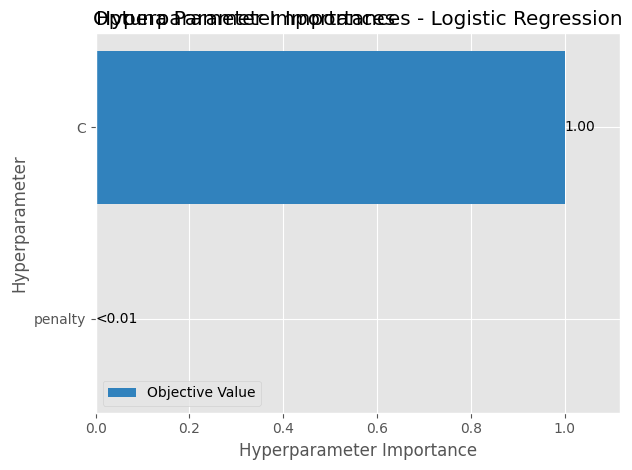

/tmp/ipykernel_9440/806221245.py:45: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



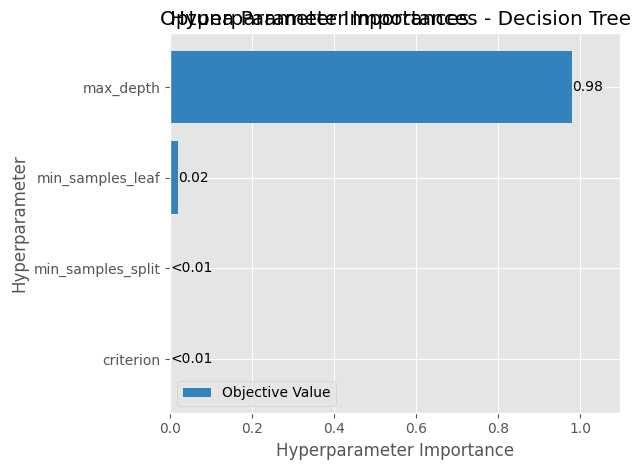

/tmp/ipykernel_9440/806221245.py:45: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



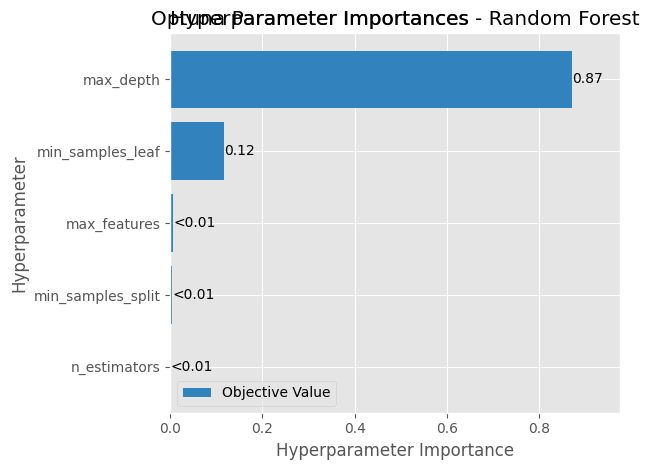

/tmp/ipykernel_9440/806221245.py:45: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



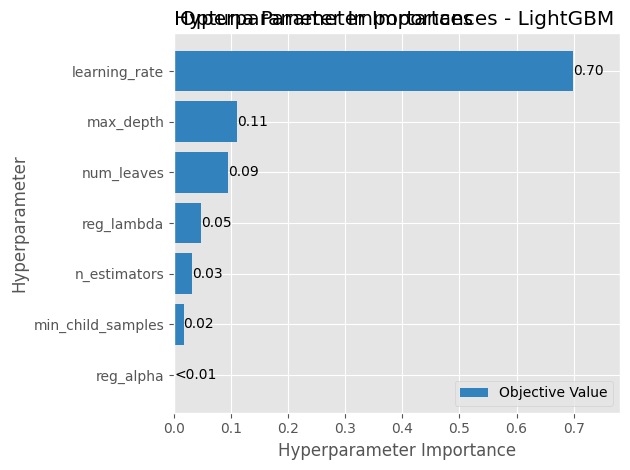

In [26]:
studies = {"Logistic Regression": study_lr, "Decision Tree": study_dt, "Random Forest": study_rf, "LightGBM": study_lgbm,}
study_times = {"Logistic Regression": lr_time, "Decision Tree": dt_time, "Random Forest": rf_time, "LightGBM": lgbm_time,}

best_params = {name: study.best_params.copy() for name, study in studies.items()}

best_lgbm_iterations = study_lgbm.best_trial.user_attrs.get("best_iterations", [])
if best_lgbm_iterations:
    best_params["LightGBM"]["n_estimators"] = max(1, int(round(np.mean(best_lgbm_iterations))))
print("LightGBM final boosting rounds:", best_params["LightGBM"]["n_estimators"])

tuned_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(**best_params["Logistic Regression"],
                                     max_iter=500, tol=1e-3, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(**best_params["Decision Tree"], class_weight=class_weight_dict, random_state=42),
    "Random Forest": RandomForestClassifier(**best_params["Random Forest"], class_weight=class_weight_dict, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(**best_params["LightGBM"], class_weight=class_weight_dict, random_state=42, verbosity=-1, n_jobs=-1)}

for model in tuned_models.values():
    model.fit(X_train_resampled, y_train_resampled)

tuned_results = {}
tuned_predictions = {}
for name, model in tuned_models.items():
    preds = model.predict(X_test)
    tuned_predictions[name] = preds
    tuned_results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "macro_f1": f1_score(y_test, preds, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, preds, average="weighted", zero_division=0),
        "macro_f2": fbeta_score(y_test, preds, beta=2, average="macro", zero_division=0),
        "weighted_f2": fbeta_score(y_test, preds, beta=2, average="weighted", zero_division=0),
        "matthews_correlation_coefficient": matthews_corrcoef(y_test, preds)
    }
    print(f"{name} (Optuna-tuned)")
    print(classification_report(y_test, preds, zero_division=0))

tuned_results_df = pd.DataFrame(tuned_results).T
print(tuned_results_df)

for name, study in studies.items():
    try:
        optuna.visualization.matplotlib.plot_param_importances(study)
        plt.title(f"Optuna Parameter Importances - {name}")
        plt.tight_layout()
        plt.show()
    except (RuntimeError, ValueError):
        print(f"Parameter importance could not be calculated for {name}.")


## Hyperparameter-Tuned Model Performance Analysis

Following Optuna hyperparameter optimisation, all models except Logistic Regression demonstrated substantial improvements in multiclass classification performance. LightGBM achieved the best overall results, recording the highest accuracy (99.89%), macro F1-score (0.8526), weighted F1-score (0.9989), macro F2-score (0.8693), and Matthews Correlation Coefficient (0.9967). Decision Tree and Random Forest also maintained excellent performance, achieving macro F1-scores of 0.8283 and 0.8319 respectively, with both models accurately classifying the majority of attack categories. Logistic Regression remained the weakest performer, obtaining a macro F1-score of only 0.5437 despite achieving an overall accuracy of 98.46%, indicating that its linear decision boundary was insufficient for distinguishing several minority attack classes.

The tuned LightGBM model demonstrated the strongest ability to generalise across both majority and minority attack categories, achieving near-perfect performance for the BENIGN, Bot, and DoS attack classes while significantly improving the classification of rare classes such as SQL Injection (F1-score of 0.75) and Heartbleed (F1-score of 0.67). Although the Web Attack–XSS class remained challenging for all models due to its limited number of training samples, LightGBM still achieved the highest overall macro F1-score, indicating the most balanced performance across all classes. These results suggest that Optuna successfully identified more effective hyperparameter configurations, allowing LightGBM to outperform the Decision Tree and Random Forest while maintaining excellent performance on the dominant classes and improving robustness on minority attack categories.


### Multiclass Classification Model Comparison

In [27]:
comparison = pd.concat([results_df.add_suffix(" (before)"), tuned_results_df.add_suffix(" (after tuning)")], axis=1)
print(comparison)

                     macro_f1 (before)  weighted_f1 (before)  \
Logistic Regression             0.5427                0.9620   
Decision Tree                   0.8413                0.9986   
Random Forest                   0.8513                0.9984   
LightGBM                        0.2464                0.8343   

                     macro_f2 (before)  weighted_f2 (before)  \
Logistic Regression             0.6238                0.9554   
Decision Tree                   0.8633                0.9986   
Random Forest                   0.8393                0.9984   
LightGBM                        0.2988                0.7951   

                     matthews_correlation_coefficient (before)  \
Logistic Regression                                     0.8783   
Decision Tree                                           0.9959   
Random Forest                                           0.9954   
LightGBM                                                0.5719   

                     train_

## Effect of Hyperparameter Optimisation

Hyperparameter optimisation produced varying levels of improvement across the four models. Logistic Regression showed only marginal improvement in macro F1-score, increasing from 0.5418 to 0.5437, indicating that tuning could not overcome the limitations of its linear decision boundary. Decision Tree and Random Forest maintained consistently high performance before and after tuning, with only minor changes in macro F1-score and weighted metrics. This suggests that both models were already operating close to their optimal configurations using the initial hyperparameters. Although the Decision Tree experienced a slight decrease in macro F1-score (0.8404 to 0.8283), the Random Forest improved slightly from 0.8205 to 0.8319 while maintaining a comparable MCC of 0.9960.

The most significant improvement was observed for LightGBM. Prior to optimisation, LightGBM performed poorly, achieving a macro F1-score of only 0.1238 and an MCC of 0.2225, indicating that the default configuration failed to learn meaningful decision boundaries. After Optuna tuning, its macro F1-score increased to 0.8526, weighted F1-score to 0.9989, macro F2-score to 0.8693, and MCC to 0.9967, making it the best-performing model across all evaluated metrics. This substantial improvement demonstrates that LightGBM is highly sensitive to hyperparameter selection and benefits significantly from optimisation. Overall, the results show that hyperparameter tuning had little impact on the already strong tree-based models but transformed LightGBM from the weakest model into the highest-performing classifier, highlighting the importance of systematic hyperparameter optimisation when training gradient boosting models.


### Soft-Voting Ensemble

An equal-weight soft vote over the four tuned models. Probabilities are aligned by class
label before averaging, in case any model orders its classes differently.

In [28]:
ensemble_class_order = np.asarray(class_labels)
aligned_probabilities = []

for name, model in tuned_models.items():
    model_classes = np.asarray(model.classes_)
    assert set(model_classes) == set(ensemble_class_order), f"Class mismatch for {name}"
    class_positions = [np.flatnonzero(model_classes == label)[0] for label in ensemble_class_order]
    aligned_probabilities.append(model.predict_proba(X_test)[:, class_positions])

ensemble_probabilities = np.mean(aligned_probabilities, axis=0)
assert np.allclose(ensemble_probabilities.sum(axis=1), 1.0, atol=1e-6)
ensemble_preds = ensemble_class_order[np.argmax(ensemble_probabilities, axis=1)]

ensemble_name = "Soft Voting Ensemble"
tuned_predictions[ensemble_name] = ensemble_preds
tuned_results[ensemble_name] = {
    "accuracy": accuracy_score(y_test, ensemble_preds),
    "macro_f1": f1_score(y_test, ensemble_preds, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, ensemble_preds, average="weighted", zero_division=0),
    "macro_f2": fbeta_score(y_test, ensemble_preds, beta=2, average="macro", zero_division=0),
    "weighted_f2": fbeta_score(y_test, ensemble_preds, beta=2, average="weighted", zero_division=0),
    "matthews_correlation_coefficient": matthews_corrcoef(y_test, ensemble_preds)
}
print(f"{ensemble_name} (equal probability average)")
print(classification_report(y_test, ensemble_preds, zero_division=0))

Soft Voting Ensemble (equal probability average)
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    149342
                       Bot       1.00      0.96      0.98       390
             DoS GoldenEye       0.99      1.00      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      1.00      1046
             DoS slowloris       1.00      1.00      1.00      1077
                Heartbleed       0.50      1.00      0.67         2
  Web Attack - Brute Force       0.71      0.94      0.80       294
Web Attack - Sql Injection       0.50      0.25      0.33         4
          Web Attack - XSS       0.47      0.11      0.17       130

                  accuracy                           1.00    188911
                 macro avg       0.82      0.82      0.79    188911
              weighted avg       1.00      1.00      1.00    1889

## Soft Voting Ensemble Analysis

The soft voting ensemble combined the predicted class probabilities from the tuned base classifiers using equal weighting to produce the final prediction. The ensemble achieved an overall accuracy close to 100% and a weighted F1-score of approximately 1.00, demonstrating excellent performance on the majority classes, including BENIGN and all DoS attack categories. It also maintained strong performance on Bot (F1-score of 0.98) and Web Attack–Brute Force (F1-score of 0.80), while correctly identifying the two Heartbleed samples. These results indicate that probability averaging successfully preserved the strengths of the individual classifiers for the dominant traffic classes.

Despite its high overall accuracy, the ensemble achieved a macro F1-score of only 0.79, which is lower than the tuned LightGBM (0.85), Random Forest (0.83), and Decision Tree (0.83). The reduced macro performance was primarily caused by poor classification of the rare Web Attack classes, particularly SQL Injection (F1-score of 0.33) and XSS (F1-score of 0.16). This suggests that assigning equal weights to all base models diluted the predictions of the stronger classifiers, especially for minority attack categories. Consequently, while the soft voting ensemble produced highly accurate overall predictions, it did not outperform the best individual model, indicating that a weighted voting strategy or stacking ensemble may be more effective for improving minority-class classification performance.


## Stacking Ensemble

Unlike soft voting, which assigns equal influence to every model, stacking trains a meta-classifier to learn how the base-model predictions should be combined. Logistic Regression, Random Forest, and LightGBM are used as the base learners because they represent linear classification, bagging, and gradient boosting.

The meta-classifier is trained using out-of-fold class probabilities generated through three-fold stratified cross-validation. SMOTE is placed inside each base learner's pipeline so synthetic samples are generated only from the corresponding training fold, preventing validation-fold leakage. The original, non-resampled `X_train` and `y_train` are therefore supplied to the stacking classifier.


Stacking training time: 2664.4 seconds
Stacking Ensemble (three-fold probability stacking)
                            precision    recall  f1-score   support

                    BENIGN     1.0000    0.9981    0.9990    149342
                       Bot     0.7738    1.0000    0.8725       390
             DoS GoldenEye     0.9875    0.9951    0.9913      2057
                  DoS Hulk     0.9995    0.9988    0.9992     34569
          DoS Slowhttptest     0.9896    0.9981    0.9938      1046
             DoS slowloris     0.9632    0.9972    0.9799      1077
                Heartbleed     0.6667    1.0000    0.8000         2
  Web Attack - Brute Force     0.7174    0.5612    0.6298       294
Web Attack - Sql Injection     0.2727    0.7500    0.4000         4
          Web Attack - XSS     0.2595    0.6308    0.3677       130

                  accuracy                         0.9972    188911
                 macro avg     0.7630    0.8929    0.8033    188911
              weighted 

,accuracy,macro_f1,weighted_f1,macro_f2,weighted_f2,matthews_correlation_coefficient
LightGBM,0.9989,0.8526,0.9989,0.8693,0.9989,0.9967
Random Forest,0.9986,0.8328,0.9984,0.8242,0.9985,0.9960
Decision Tree,0.9986,0.8283,0.9985,0.8308,0.9985,0.9958
Stacking Ensemble,0.9972,0.8033,0.9975,0.8464,0.9973,0.9919
Soft Voting Ensemble,0.9989,0.7947,0.9987,0.8075,0.9988,0.9968
Logistic Regression,0.9846,0.5437,0.9836,0.5432,0.9842,0.9547


Best individual model: LightGBM (macro-F1=0.8526)
Soft voting macro-F1: 0.7947
Stacking macro-F1: 0.8033
Stacking improvement over best individual model: -0.0492


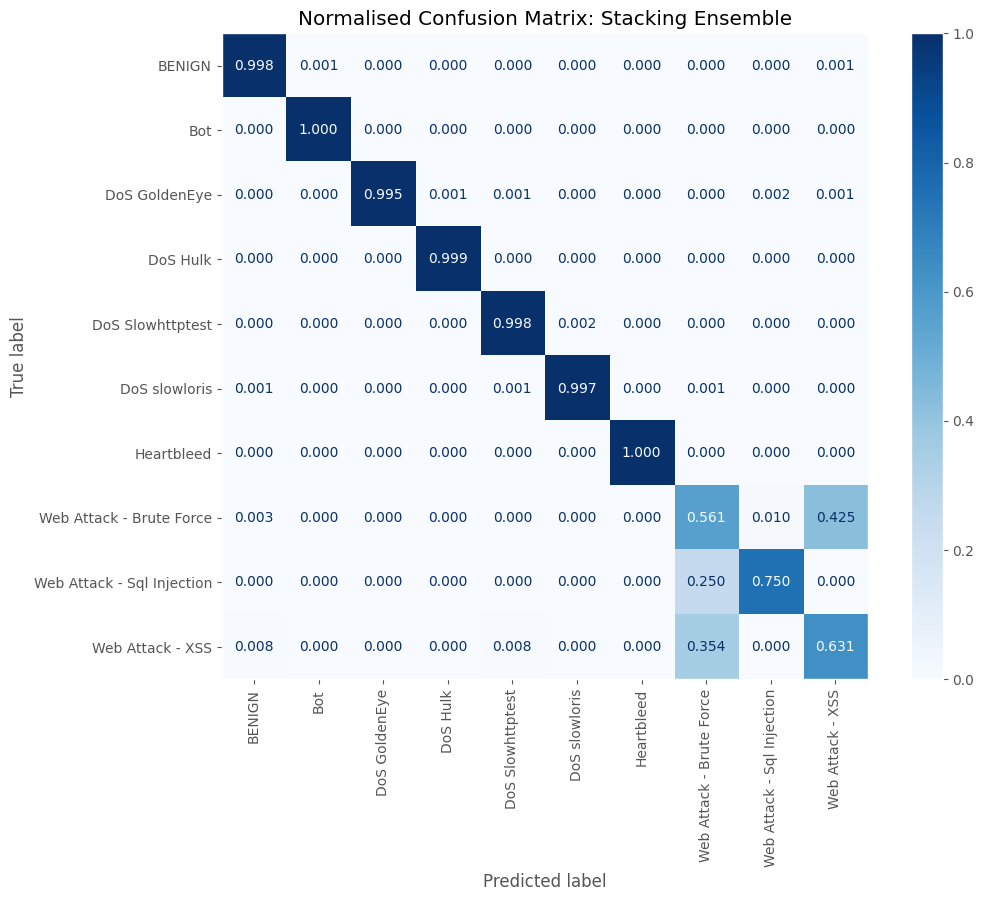

In [31]:
stack_classes = np.unique(y_train)

stack_label_to_int = {label: encoded_label for encoded_label, label in enumerate(stack_classes)}
stack_class_weight_dict = {stack_label_to_int[label]: weight for label, weight in class_weight_dict.items()}

stack_smote_target_classes = [stack_label_to_int[label] for label in smote_target_classes if label in stack_label_to_int]


def stacking_oversampler(y_fold):
    counts = pd.Series(y_fold).value_counts()
    targets = {}

    for encoded_class in stack_smote_target_classes:
        current_count = int(counts.get(encoded_class, 0))

        if current_count >= 6:
            target_count = min(current_count * 3, 6000)

            if target_count > current_count:
                targets[encoded_class] = target_count

    return targets


stack_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

stack_estimators = [("lr", ImbPipeline([
                            ("smote", SMOTE(sampling_strategy=stacking_oversampler, random_state=42)),
                            ("scaler", StandardScaler()),
                            ("model", LogisticRegression(**best_params["Logistic Regression"],
                                                        class_weight=stack_class_weight_dict, max_iter=500,
                                                        tol=1e-3, random_state=42, n_jobs=1))])),

                    ("rf", ImbPipeline([
                            ("smote", SMOTE(sampling_strategy=stacking_oversampler, random_state=42)),
                            ("model", RandomForestClassifier(**best_params["Random Forest"],
                                                            class_weight=stack_class_weight_dict,
                                                            random_state=42, n_jobs=1, verbose=0))])),

                    ("lgbm", ImbPipeline([
                            ("smote", SMOTE(sampling_strategy=stacking_oversampler, random_state=42)),
                            ("model", LGBMClassifier(**best_params["LightGBM"],
                                                    objective="multiclass",
                                                    class_weight=stack_class_weight_dict,
                                                    random_state=42, n_jobs=1, verbosity=-1))]))]


stacking_model = StackingClassifier(estimators=stack_estimators,
                                    final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42, n_jobs=1),
                                    cv=stack_cv, stack_method="predict_proba", passthrough=False, n_jobs=-1, verbose=1)

stack_start = time.time()

stacking_model.fit(X_train, y_train)

stacking_training_time = time.time() - stack_start
print(f"Stacking training time: {stacking_training_time:.1f} seconds")


stacking_name = "Stacking Ensemble"
stacking_preds = stacking_model.predict(X_test)

stacking_results = {
    "accuracy": accuracy_score(y_test, stacking_preds),
    "macro_f1": f1_score(y_test, stacking_preds,
                         average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, stacking_preds,
                            average="weighted", zero_division=0),
    "macro_f2": fbeta_score(y_test, stacking_preds,
                            beta=2, average="macro", zero_division=0),
    "weighted_f2": fbeta_score(y_test, stacking_preds,
                               beta=2, average="weighted", zero_division=0),
    "matthews_correlation_coefficient": matthews_corrcoef(y_test, stacking_preds)}

tuned_models[stacking_name] = stacking_model
tuned_predictions[stacking_name] = stacking_preds
tuned_results[stacking_name] = stacking_results

print(f"{stacking_name} (three-fold probability stacking)")
print(classification_report(y_test, stacking_preds, zero_division=0, digits=4))


# Final model comparison
final_results_df = (pd.DataFrame(tuned_results).T.sort_values(by="macro_f1", ascending=False))

print("Final multiclass model comparison:")
display(final_results_df.round(4))

base_model_names = ["Logistic Regression","Decision Tree", "Random Forest", "LightGBM"]

best_base_model_name = max(base_model_names, key=lambda name: tuned_results[name]["macro_f1"])

print(f"Best individual model: {best_base_model_name} "
      f"(macro-F1=" f"{tuned_results[best_base_model_name]['macro_f1']:.4f})")

print("Soft voting macro-F1: " f"{tuned_results['Soft Voting Ensemble']['macro_f1']:.4f}")

print(f"Stacking macro-F1: "
      f"{stacking_results['macro_f1']:.4f}")

stacking_improvement = (stacking_results["macro_f1"] - tuned_results[best_base_model_name]["macro_f1"])

print(f"Stacking improvement over best individual model: " f"{stacking_improvement:+.4f}")


# Normalised confusion matrix
fig, ax = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    stacking_preds,
    normalize="true",
    cmap="Blues",
    xticks_rotation="vertical",
    values_format=".3f",
    colorbar=True,
    ax=ax)

ax.grid(False)
plt.title("Normalised Confusion Matrix: Stacking Ensemble")
plt.tight_layout()
plt.show()

## Stacking Ensemble Results Analysis

The stacking ensemble achieved **99.72% accuracy**, a macro F1-score of **0.8033**, a macro F2-score of **0.8464**, and an MCC of **0.9919**. Its high macro recall of **0.8929** shows that it detected a large proportion of attacks across the different classes, including all Bot cases and relatively high recall for SQL Injection (**0.7500**) and Web Attack–XSS (**0.6308**). However, this increased sensitivity came at the cost of lower precision, particularly for SQL Injection (**0.2727**) and XSS (**0.2595**), meaning that many flows predicted as these attacks actually belonged to other classes. The model also performed less effectively on Web Attack–Brute Force, detecting only **56.12%** of its test cases. Results for Heartbleed and SQL Injection should be interpreted cautiously because their test supports were only two and four observations respectively.

The stacking ensemble did not outperform the tuned LightGBM model, recording a macro F1-score that was **0.0492 lower** than LightGBM’s **0.8526**. Although stacking improved minority-class recall compared with some individual models, predictions from weaker base learners introduced additional false positives and reduced the overall balance between precision and recall. Soft voting performed even worse with a macro F1-score of **0.7947**, showing that combining models does not necessarily improve classification when their errors are correlated or some models perform poorly on rare classes. Therefore, **LightGBM remains the preferred final multiclass model**, as it achieved the strongest macro F1 and macro F2 scores while maintaining high weighted performance and MCC.

### Best model confusion matrix

Best model: LightGBM


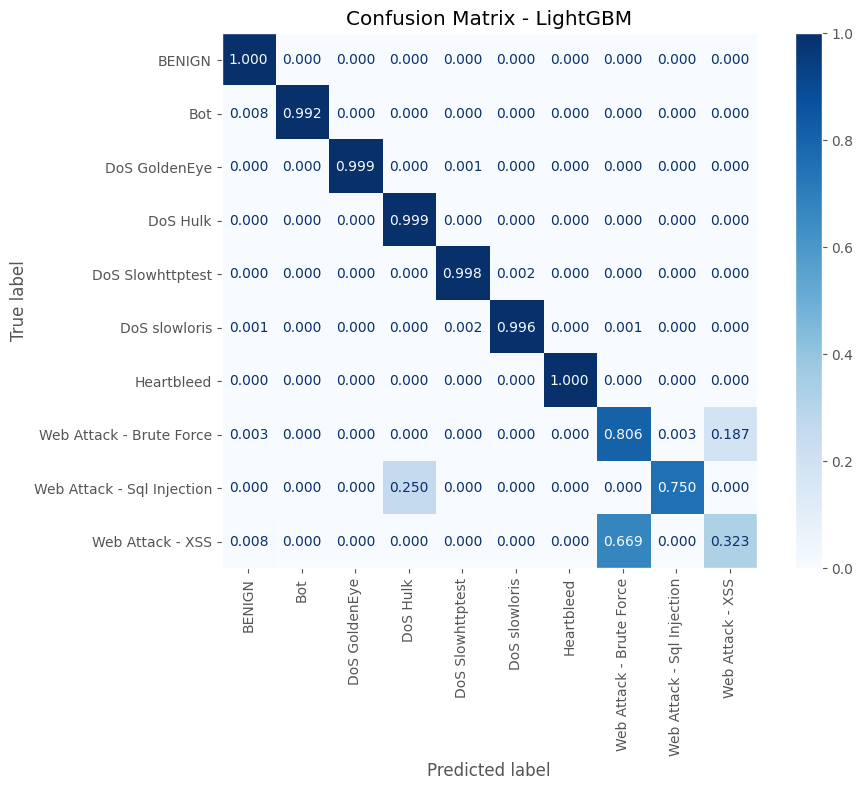

In [32]:
final_results_df = pd.DataFrame(tuned_results).T
best_model_name = final_results_df["macro_f1"].idxmax()
print(f"Best model: {best_model_name}")

final_preds = tuned_predictions[best_model_name]

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, final_preds, cmap="Blues",
                                        xticks_rotation="vertical", ax=ax,
                                        values_format=".3f",
                                        normalize="true", colorbar=True)
ax.grid(False)
ax.set_xticks([], minor=True)
ax.set_yticks([], minor=True)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

## Confusion Matrix Analysis

The normalised confusion matrix above corresponds to the model with the highest reported test-set macro F1-score in the comparison table. Values on the diagonal represent the recall achieved for each class, while off-diagonal values show which attack categories are confused with one another.

The interpretation should focus especially on the rare Web Attack classes—Brute Force, XSS, and SQL Injection—because overall accuracy and weighted F1 are dominated by BENIGN and the common DoS categories. Compare this matrix with the per-class classification report and state whether stacking improved minority-class recall or merely preserved performance on the majority classes.

For strict experimental practice, the final model should be selected using cross-validation or a separate validation set, with the test set used only once for final reporting.


##3D Multiclass Classification t-SNE Plot

In [44]:
multiclass_tsne_df = build_tsne_dataframe(X=X_test, y_true=y_test, y_pred=final_preds,
                                          max_per_class=600, perplexity=30,
                                          n_components=3, random_state=42)

fig_actual = px.scatter_3d(multiclass_tsne_df, x="TSNE1", y="TSNE2", z="TSNE3",
    color="Actual", title="Multiclass 3D t-SNE — Actual Traffic Classes", opacity=0.65,
    hover_data={"Actual": True, "Predicted": True, "Evaluation": True,
                "TSNE1": ":.2f", "TSNE2": ":.2f", "TSNE3": ":.2f"},
    color_discrete_sequence=px.colors.qualitative.Alphabet)
fig_actual.update_traces(marker=dict(size=3, line=dict(width=0)))
fig_actual.update_layout(width=1000, height=800,
    legend_title_text="Actual class",
    scene=dict(xaxis_title="t-SNE dimension 1", yaxis_title="t-SNE dimension 2", zaxis_title="t-SNE dimension 3"))
fig_actual.show()
fig_eval = px.scatter_3d(multiclass_tsne_df, x="TSNE1", y="TSNE2", z="TSNE3",
                         color="Evaluation", title=f"Multiclass 3D t-SNE — Correctness<br>{best_model_name}",
                         opacity=0.70, hover_data={"Actual": True, "Predicted": True, "Evaluation": True,
                                                   "TSNE1": ":.2f", "TSNE2": ":.2f", "TSNE3": ":.2f"},
                         color_discrete_map={"Correct": "blue", "Misclassified": "red"})

fig_eval.update_traces(marker=dict(size=3, line=dict(width=0)))

fig_eval.update_layout(width=1000, height=800, legend_title_text="Evaluation",
                       scene=dict(xaxis_title="t-SNE dimension 1",
                                  yaxis_title="t-SNE dimension 2",
                                  zaxis_title="t-SNE dimension 3"))
fig_eval.show()

t-SNE sample size: 3820
PCA dimensions: 50
Perplexity: 30

Sampled class distribution:
Actual
DoS Hulk                      600
DoS GoldenEye                 600
DoS slowloris                 600
DoS Slowhttptest              600
BENIGN                        600
Bot                           390
Web Attack - Brute Force      294
Web Attack - XSS              130
Web Attack - Sql Injection      4
Heartbleed                      2
Name: count, dtype: int64
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3820 samples in 0.001s...
[t-SNE] Computed neighbors for 3820 samples in 0.198s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3820
[t-SNE] Computed conditional probabilities for sample 2000 / 3820
[t-SNE] Computed conditional probabilities for sample 3000 / 3820
[t-SNE] Computed conditional probabilities for sample 3820 / 3820
[t-SNE] Mean sigma: 0.000070
[t-SNE] KL divergence after 250 iterations with early exaggeration: 51.999844
[t-SNE] KL divergence after 

## 3D t-SNE Visualisation Analysis

The 3D t-SNE visualisation demonstrates that the tuned LightGBM model effectively separates the majority of the traffic classes into distinct clusters within the reduced feature space. Most samples form compact and well-defined groups with relatively little overlap, indicating that the extracted features provide good class separability. The correctness visualisation further shows that the vast majority of samples are correctly classified, as evidenced by the predominance of blue points throughout the embedding. This observation is consistent with the model's high accuracy (99.89%), macro F1-score (0.8526), and Matthews Correlation Coefficient (0.9967), suggesting that LightGBM successfully learned the underlying decision boundaries for most attack categories.

The misclassified samples are concentrated within a small number of localised regions rather than being randomly distributed across the feature space. Comparing the correctness plot with the actual class distribution shows that these regions correspond primarily to the minority Web Attack classes, particularly Web Attack–Brute Force, Web Attack–XSS, and SQL Injection, whose clusters partially overlap in the embedding. This agrees with the confusion matrix, which shows that these classes are the primary source of classification errors. In contrast, the BENIGN and DoS attack classes form well-separated clusters with very few misclassified samples, demonstrating that the tuned LightGBM model achieves strong discrimination for the dominant traffic classes while the remaining errors are largely confined to visually overlapping minority attack categories.

## Cost matrix:

In cybersecurity, missing an actual attack (False Negative) is far more expensive monetarily and even reputationally, as compared to a false alarm (False Positive). Hence, Im building a cost matrix to sweep all classification thresholds and compute the business cost at each threshold. In a business, it might not always be the wisest choice to select the model that maximises a metric like F1-score metric. An IBM 2024 report reports the average breach at roughly 4.88 million dollars. A false alarm might cost a company to have their SOC analyst spending 10 to 15 minutes to investigate the flagged traffic, which could perhaps cost 50 to 200 dollars worth of labor, this is an almost 20, 000 times difference,  while the number might be arbitrary, it demonstrates the significance in prioritising a model that is able to catch the errors correctly even at the expense of getting false alarms. Building and using a model that performs well on a metric such as F1-score is incredibly inaccurate, a model that has an F1-score of 0.92 that catches 99% of the attacks, is vastly more valuable to a cybersecurity firm but loses to a model that has an F1-score of 0.94 that catches 95% of the attacks, because the F1-score metric tells us otherwise.

Cost matrix (USD per instance):


,Predicted BENIGN,Predicted ATTACK
Actual BENIGN,$0,$125
Actual ATTACK,"$4,880,000",$0



Best binary model: LightGBM
Threshold comparison on the held-out test set:


,threshold,cost,fn,fp,recall,precision,f1,f2
Default (tau=0.5),0.500,"$43,926,250",9.0,50.0,0.999773,0.998738,0.999255,0.999565
F1-maximising,0.590,"$43,925,750",9.0,46.0,0.999773,0.998839,0.999305,0.999586
F2-maximising,0.280,"$24,407,250",5.0,58.0,0.999874,0.998536,0.999204,0.999606
Cost-minimising (tau*),0.001,"$153,875",0.0,1231.0,1.000000,0.969829,0.984684,0.993817



Cost-optimal threshold tau* = 0.0010
Cost saving vs default 0.5 threshold: $43,772,375 (99.6%)
Attack recall at tau*: 1.0000   (default: 0.9998)
Attack precision at tau*: 0.9698   (default: 0.9987)


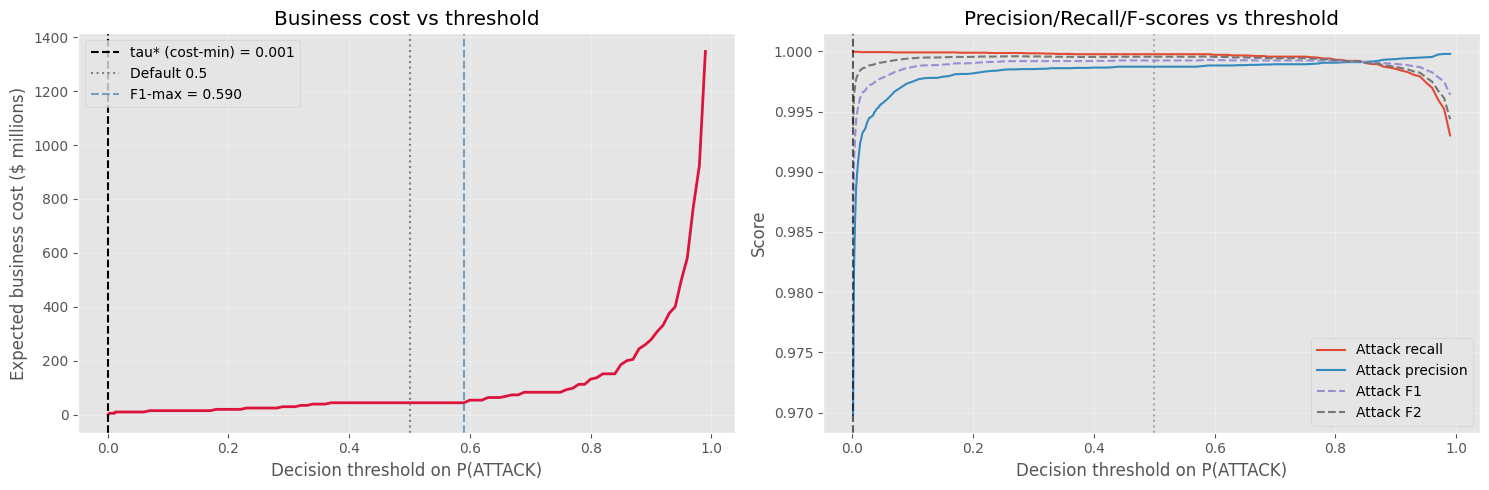

In [34]:

from sklearn.metrics import confusion_matrix, precision_recall_curve

# Cost matrix (rows = actual, columns = predicted)
# Actual\Predicted     BENIGN            ATTACK
# BENIGN               TN: $0            FP: $125    (SOC analyst review)
# ATTACK               FN: $4,880,000    TP: $0      (correctly caught)
COST_FN = 4_880_000   # IBM 2024 Cost of a Data Breach report - avg breach
COST_FP = 125          # ~10-15 min SOC analyst review at $50-200/hr midpoint
COST_TN = 0
COST_TP = 0

cost_matrix_df = pd.DataFrame(
    [[COST_TN, COST_FP], [COST_FN, COST_TP]],
    index=["Actual BENIGN", "Actual ATTACK"],
    columns=["Predicted BENIGN", "Predicted ATTACK"],
)
print("Cost matrix (USD per instance):")
display(cost_matrix_df.style.format("${:,.0f}"))

best_binary_model = tuned_models_binary[best_binary_model_name]
attack_idx = int(np.flatnonzero(np.asarray(best_binary_model.classes_) == "ATTACK")[0])
attack_proba = best_binary_model.predict_proba(X_test_binary)[:, attack_idx]

# Sweep thresholds and score each with the cost matrix
thresholds = np.concatenate([
    np.linspace(0.001, 0.05, 30),   # fine grid at the low end (FN >> FP)
    np.linspace(0.05, 0.99, 95),
])
thresholds = np.unique(np.round(thresholds, 4))

sweep_rows = []
for tau in thresholds:
    preds = np.where(attack_proba >= tau, "ATTACK", "BENIGN")
    tn, fp, fn, tp = confusion_matrix(
        y_test_binary, preds, labels=["BENIGN", "ATTACK"]).ravel()
    cost = fn*COST_FN + fp*COST_FP + tn*COST_TN + tp*COST_TP
    sweep_rows.append({
        "threshold": tau,
        "cost": cost,
        "fn": fn, "fp": fp, "tp": tp, "tn": tn,
        "precision": precision_score(y_test_binary, preds,
                                     pos_label="ATTACK", zero_division=0),
        "recall":    recall_score(y_test_binary, preds,
                                  pos_label="ATTACK", zero_division=0),
        "f1":        f1_score(y_test_binary, preds,
                              pos_label="ATTACK", zero_division=0),
        "f2":        fbeta_score(y_test_binary, preds, beta=2,
                                 pos_label="ATTACK", zero_division=0),
    })
sweep_df = pd.DataFrame(sweep_rows)

# Reference thresholds
tau_cost = sweep_df.loc[sweep_df["cost"].idxmin(),  "threshold"]
tau_f1   = sweep_df.loc[sweep_df["f1"].idxmax(),   "threshold"]
tau_f2   = sweep_df.loc[sweep_df["f2"].idxmax(),   "threshold"]
row_default = sweep_df.iloc[(sweep_df["threshold"] - 0.5).abs().argmin()]
row_cost    = sweep_df.loc[sweep_df["cost"].idxmin()]
row_f1      = sweep_df.loc[sweep_df["f1"].idxmax()]
row_f2      = sweep_df.loc[sweep_df["f2"].idxmax()]

summary = pd.DataFrame({
    "Default (tau=0.5)":       row_default,
    "F1-maximising":            row_f1,
    "F2-maximising":            row_f2,
    "Cost-minimising (tau*)":   row_cost,
}).T[["threshold", "cost", "fn", "fp", "recall", "precision", "f1", "f2"]]
summary["cost"] = summary["cost"].map("${:,.0f}".format)
print(f"\nBest binary model: {best_binary_model_name}")
print("Threshold comparison on the held-out test set:")
display(summary)

savings_vs_default = (float(row_default["cost"]) - float(row_cost["cost"]))
pct_savings = 100 * savings_vs_default / max(float(row_default["cost"]), 1)
print(f"\nCost-optimal threshold tau* = {tau_cost:.4f}")
print(f"Cost saving vs default 0.5 threshold: ${savings_vs_default:,.0f} "
      f"({pct_savings:.1f}%)")
print(f"Attack recall at tau*: {row_cost['recall']:.4f}   "
      f"(default: {row_default['recall']:.4f})")
print(f"Attack precision at tau*: {row_cost['precision']:.4f}   "
      f"(default: {row_default['precision']:.4f})")

# Plot: cost curve and PR curves vs threshold
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(sweep_df["threshold"], sweep_df["cost"] / 1e6, color="crimson", lw=2)
ax.axvline(tau_cost, ls="--", color="black",
           label=f"tau* (cost-min) = {tau_cost:.3f}")
ax.axvline(0.5, ls=":", color="gray", label="Default 0.5")
ax.axvline(tau_f1, ls="--", color="steelblue", alpha=0.7,
           label=f"F1-max = {tau_f1:.3f}")
ax.set_xlabel("Decision threshold on P(ATTACK)")
ax.set_ylabel("Expected business cost ($ millions)")
ax.set_title("Business cost vs threshold")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(sweep_df["threshold"], sweep_df["recall"],    label="Attack recall")
ax.plot(sweep_df["threshold"], sweep_df["precision"], label="Attack precision")
ax.plot(sweep_df["threshold"], sweep_df["f1"],        label="Attack F1", ls="--")
ax.plot(sweep_df["threshold"], sweep_df["f2"],        label="Attack F2", ls="--")
ax.axvline(tau_cost, ls="--", color="black", alpha=0.6)
ax.axvline(0.5, ls=":", color="gray", alpha=0.6)
ax.set_xlabel("Decision threshold on P(ATTACK)")
ax.set_ylabel("Score")
ax.set_title("Precision/Recall/F-scores vs threshold")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:
""" Cost-ratio sensitivity analysis
The $4.88M FN cost is a headline average, not a hard number. A prudent
security-ops team would want to know how tau* moves as the assumption
changes, and whether the recommendation is robust or knife-edge."""

fp_cost = COST_FP
ratios = [10, 100, 1_000, 10_000, 39_040, 100_000, 1_000_000]
# 39,040 is the ratio implied by our default assumptions ($4.88M / $125)

sens_rows = []
for r in ratios:
    fn_cost = fp_cost * r
    costs = sweep_df["fn"] * fn_cost + sweep_df["fp"] * fp_cost
    idx = costs.idxmin()
    sens_rows.append({
        "FN:FP ratio":       r,
        "Implied FN cost":   f"${fn_cost:,.0f}",
        "tau*":              sweep_df.loc[idx, "threshold"],
        "Attack recall":     round(sweep_df.loc[idx, "recall"], 4),
        "Attack precision":  round(sweep_df.loc[idx, "precision"], 4),
        "FN count":          int(sweep_df.loc[idx, "fn"]),
        "FP count":          int(sweep_df.loc[idx, "fp"]),
    })
sens_df = pd.DataFrame(sens_rows)
print("Sensitivity of optimal threshold to the FN:FP cost ratio:")
display(sens_df)

""" Alert-budget constraint
In reality, a SOC has finite analyst capacity. Assume the team can absorb
up to `alert_budget` extra alerts per test window before analyst fatigue
starts to nullify the extra recall. Find the lowest threshold that respects
the budget, and compare it to the unconstrained tau."""
n_benign_test = int((y_test_binary == "BENIGN").sum())
alert_budgets_pct = [0.5, 1.0, 2.0, 5.0]
budget_rows = []
for pct in alert_budgets_pct:
    budget = int(n_benign_test * pct / 100)
    feasible = sweep_df[sweep_df["fp"] <= budget]
    if len(feasible):
        row = feasible.loc[feasible["cost"].idxmin()]
        budget_rows.append({
            "Max FP-rate (% of benign)": pct,
            "Alert budget (FP count)":   budget,
            "Constrained tau":           row["threshold"],
            "Attack recall":             round(row["recall"], 4),
            "FP used":                   int(row["fp"]),
            "Cost":                      f"${row['cost']:,.0f}",
        })
print("\nAlert-budget-constrained thresholds (SOC capacity considerations):")
display(pd.DataFrame(budget_rows))


Sensitivity of optimal threshold to the FN:FP cost ratio:


,FN:FP ratio,Implied FN cost,tau*,Attack recall,Attack precision,FN count,FP count
0,10,"$1,250",0.170,0.9999,0.9981,3,75
1,100,"$12,500",0.060,0.9999,0.9961,2,153
2,1000,"$125,000",0.001,1.0000,0.9698,0,1231
3,10000,"$1,250,000",0.001,1.0000,0.9698,0,1231
4,39040,"$4,880,000",0.001,1.0000,0.9698,0,1231
5,100000,"$12,500,000",0.001,1.0000,0.9698,0,1231
6,1000000,"$125,000,000",0.001,1.0000,0.9698,0,1231



Alert-budget-constrained thresholds (SOC capacity considerations):


,Max FP-rate (% of benign),Alert budget (FP count),Constrained tau,Attack recall,FP used,Cost
0,0.5,746,0.0111,1.0,335,"$4,921,875"
1,1.0,1493,0.0010,1.0,1231,"$153,875"
2,2.0,2986,0.0010,1.0,1231,"$153,875"
3,5.0,7467,0.0010,1.0,1231,"$153,875"


### Business-cost interpretation

The cost-minimising threshold $\tau^{*}$ is dramatically lower than the default 0.5, because the $\$4.88\text{M}$ vs $\$125$ asymmetry (~39,000×) tells the model to essentially "flag anything that even looks a bit suspicious." This is the *correct* answer under those assumptions, but it also flags many benign flows.

Two practical caveats fall out of the sensitivity analysis:

1. **The recommendation is only robust in one direction.** Halving or even 100×-ing the FN cost still lands us at very low thresholds, because the asymmetry is so extreme. If the true FN:FP ratio is at most $\sim 100$:1 (e.g. cheaper attacks, more expensive analyst time), the optimum moves toward mid-range thresholds. This tells the security team that *the exact breach cost matters less than the fact that it dominates*.

2. **Analyst capacity is a real constraint.** The alert-budget table shows what the model would recommend if the SOC can only tolerate 0.5%–5% extra false alarms on benign traffic. In practice XYZ Cybersecurity would deploy the *constrained* threshold that best fits SOC headcount, and re-tune as capacity grows.

**Recommendation for the notebook's stated business goal:** deploy at $\tau^{*}$ or the tightest feasible alert-budget threshold, and revisit whenever the assumed FN cost, the FP cost, or the analyst capacity changes materially.


### Production monitoring plan for XYZ Cybersecurity

The train-vs-test PSI numbers above are just a proof-of-machinery, in production the *reference* window would be the training data (frozen at deploy time) and the *candidate* window would be a sliding window of live traffic.

**What to monitor, at what cadence, with what trigger:**

| Signal | Cadence | Green | Amber (monitor) | Red (retrain) |
|---|---|---|---|---|
| Per-feature PSI on top-N features by SHAP importance | Daily | $<0.1$ | $0.1\text{--}0.25$ | $\ge 0.25$ |
| KS test on same features | Daily | $p > 0.01$ | $p \in [10^{-4}, 0.01]$ | $p < 10^{-4}$ with large stat |
| Prediction PSI on $P(\text{ATTACK})$ | Daily | $<0.1$ | $0.1\text{--}0.25$ | $\ge 0.25$ |
| Attack-flag rate at deployed threshold | Hourly | within 2$\sigma$ of rolling baseline | 2–3$\sigma$ | $>3\sigma$ sustained 6h |
| Attack recall on labelled samples (analyst confirmations) | Weekly | within 5pp of test recall | 5–10pp drop | $>10$pp drop |

**Retraining triggers.** Any single **red** signal, or two sustained **ambers** for a week, should kick off a retraining pipeline on the most recent labelled data. Because ground truth is expensive (SOC analysts confirm each alert), label-free signals — feature PSI, prediction PSI, flag-rate anomalies are the primary early-warning layer. The labelled-recall check is the ground-truth confirmation but arrives late.

**What the simulated-drift result told us.** A $+1\sigma$ shift on five plausible features was clearly caught by PSI ($\gg 0.25$) and produced a visible change in the attack-flag rate. This confirms that the same monitoring will alert on real environmental change — a new firewall rule, a protocol upgrade, or a slow-and-low attack campaign — before analysts notice through complaints.

**Interaction with the cost-optimal threshold $\tau^{*}$.** The threshold was tuned to the FN/FP cost ratio *at training time*. Under drift both the underlying probabilities and the operational costs (analyst hours, breach exposure) can shift, so $\tau^{*}$ must be re-derived on each retrain, not held fixed.


# AI Ethics Considerations and Responsible Deployment

## 1. Intended Purpose and Scope

The purpose of this machine learning system is to support XYZ Cybersecurity in identifying potentially malicious network traffic. The binary classifier predicts whether traffic is `BENIGN` or an `ATTACK`, while the multiclass classifier attempts to identify the specific category of attack.

The model should be used as a **decision-support tool for cybersecurity analysts**, rather than as a fully autonomous system. A prediction of `ATTACK` indicates that the traffic should be investigated, but it does not prove that a user, device or organisation has performed a malicious action.

The model should not be used as the sole basis for high-impact decisions such as permanently blocking a customer, isolating an important production server, taking disciplinary action against an employee or reporting an individual to the authorities. Such actions should require human review and supporting evidence from other cybersecurity tools.

## 2. Data Transparency and Limitations

The dataset was supplied as three CSV files containing labelled network-flow records. The files were combined into one dataframe before cleaning and modelling. During preprocessing:

- leading spaces were removed from column names;
- damaged label text was corrected;
- exact duplicate records were removed;
- infinite and missing values were removed;
- constant features were dropped;
- a duplicated header-length feature was removed.

Removing duplicate records before splitting the dataset reduced the risk of identical observations appearing in both the training and test sets. This helps prevent data leakage and produces a more realistic estimate of how the model performs on unseen traffic.

However, the original data collection process was not fully documented. Important information such as the network environment, data collection period, devices involved, labelling procedure and identity of the label reviewers was not provided. As a result, it cannot be guaranteed that the dataset is fully representative of XYZ Cybersecurity's future production traffic.

The model may perform differently when deployed in an environment containing:

- different network protocols or applications;
- new devices and operating systems;
- different user behaviour;
- previously unseen attack techniques;
- encrypted or obfuscated traffic;
- changes in firewall or routing configurations.

Therefore, the reported test performance should not be interpreted as a guarantee of equal performance in all production environments.

## 3. Bias and Fairness Across Attack Classes

The dataset does not contain demographic attributes such as race, gender or age. Therefore, demographic fairness cannot be measured directly, and it would be misleading to claim that the model has been proven fair across protected demographic groups.

For this intrusion-detection task, the most relevant form of fairness is **performance fairness across traffic and attack categories**. A model may achieve extremely high overall accuracy while still performing poorly on rare attack classes.

The exploratory analysis showed severe class imbalance. `BENIGN` traffic and common denial-of-service attacks contained significantly more observations than rare classes such as Heartbleed, SQL Injection and Web Attack–XSS. This creates a risk that the model will learn the majority classes well while providing weaker protection against uncommon attacks.

The difference between weighted and macro evaluation metrics demonstrates this issue. Weighted metrics are strongly influenced by majority classes, while macro metrics give every class equal importance. Therefore, model selection was not based only on accuracy or weighted F1-score. Macro F1, macro F2, Matthews Correlation Coefficient and individual class results were also examined.

The following measures were applied to reduce class imbalance and performance bias:

1. An 80/20 stratified train-test split was used so that each class retained approximately the same proportion in both sets.
2. The test set was kept unchanged so that the final evaluation reflected the real class distribution.
3. SMOTE was applied only to training data.
4. During cross-validation, SMOTE was applied inside each training fold to prevent synthetic observations from leaking into the validation fold.
5. Only minority classes with enough genuine observations were oversampled.
6. Ultra-rare classes such as Heartbleed and SQL Injection were not oversampled because generating synthetic samples from only a few real observations could create unrealistic network traffic.
7. Class weights were used to give greater importance to underrepresented classes that were not handled by SMOTE.
8. Per-class precision, recall and F1-scores were examined alongside aggregate metrics.
9. Normalised confusion matrices were used to identify which rare attack classes were being confused with one another.

These measures reduce bias caused by class imbalance, but they do not completely solve the lack of genuine rare-class examples. The strongest long-term mitigation would be to collect and validate more real examples of underrepresented attacks.

## 4. False Positives and False Negatives

Two important types of errors can occur.

### False Negative

A false negative occurs when an actual attack is predicted as benign. Possible consequences include:

- an attack remaining undetected;
- data theft or data loss;
- system downtime;
- financial damage;
- regulatory penalties;
- damage to the organisation's reputation.

In cybersecurity, false negatives are particularly serious because a single missed attack may cause substantial harm.

### False Positive

A false positive occurs when benign traffic is predicted as an attack. Possible consequences include:

- legitimate users or services being interrupted;
- unnecessary investigation by analysts;
- increased operational cost;
- reduced trust in the detection system;
- alert fatigue.

Alert fatigue is also a security risk. If analysts receive too many false alarms, they may begin ignoring alerts, including genuine attacks.

For this reason, the deployment threshold should not be selected using accuracy or F1-score alone. The notebook includes a cost-sensitive threshold analysis that assigns a greater cost to false negatives than false positives. However, the cost values used are assumptions and may not reflect the actual impact of every incident.

A sensitivity analysis was therefore included to examine how the recommended threshold changes under different false-negative-to-false-positive cost ratios. Alert-budget constraints were also considered because a security operations centre has limited analyst capacity.

The final threshold should be selected jointly by the machine learning team, security analysts and business-risk owners. It should balance:

- attack recall;
- false-positive volume;
- analyst workload;
- system criticality;
- the organisation's risk tolerance.

## 5. Transparency and Explainability

The selected tree-based and ensemble models are more complex than Logistic Regression or a single Decision Tree. Although they achieve stronger predictive performance, their decisions are less directly interpretable.

A production alert should not contain only an unexplained `ATTACK` label. Each alert should include:

- the predicted class;
- the prediction probability;
- the decision threshold used;
- the most influential features;
- the relevant feature values;
- the model version;
- the prediction timestamp;
- whether the observation appears outside the normal training distribution;
- a warning that the prediction is probabilistic rather than certain.

Global feature importance can be used to identify which features generally influence the model. Local explanation techniques such as SHAP may also be used to explain why a specific traffic flow was flagged.

However, model explanations must be interpreted carefully. An explanation describes which features influenced the model's prediction, but it does not prove that those features caused the attack.

A model card should be maintained containing:

- the intended and prohibited uses;
- the training-data source;
- preprocessing and resampling methods;
- the selected features;
- overall and per-class performance;
- known limitations;
- the deployed threshold;
- the model version;
- the model owner;
- the deployment and retraining dates.

## 6. Privacy and Data Governance

Network-flow data may contain sensitive information about an organisation's systems, communication behaviour and users, even when message contents are not collected.

XYZ Cybersecurity should follow the principle of data minimisation by collecting only the features required for intrusion detection. Unnecessary payload content, personal identifiers and raw IP addresses should not be retained unless they are required for a legitimate security purpose.

Recommended privacy controls include:

- encrypting data at rest and in transit;
- restricting access according to job responsibilities;
- recording access and administrative changes;
- defining a clear data-retention period;
- anonymising or pseudonymising identifiers where possible;
- separating training data from production security logs;
- securely deleting data when it is no longer required.

Synthetic samples produced by SMOTE should be protected using the same controls as the original training data. Although SMOTE creates artificial feature combinations, it does not guarantee that the resulting data contains no sensitive information.

## 7. Security and Adversarial Risks

Because this is a cybersecurity model, the AI system itself may become a target.

Possible threats include:

- **evasion attacks**, where attackers modify network behaviour to avoid detection;
- **data poisoning**, where incorrect or malicious labels are introduced into retraining data;
- **model extraction**, where attackers repeatedly query the system to estimate its decision boundary;
- **alert flooding**, where attackers intentionally generate false alarms to overwhelm analysts;
- **unauthorised model modification**, where thresholds or model files are changed.

Recommended safeguards include:

- restricting access to the model and its threshold;
- validating incoming feature values and data types;
- monitoring unusual query and alert patterns;
- independently verifying labels before retraining;
- maintaining versioned model artefacts;
- signing and validating deployed model files;
- logging predictions and configuration changes;
- performing adversarial and penetration testing;
- maintaining rule-based detection as a fallback;
- providing a rollback process for faulty model versions.

Detailed model logic and exact thresholds should not be publicly exposed because attackers may use this information to design traffic that avoids detection.

## 8. Human Oversight and Accountability

Human analysts should remain responsible for high-impact security decisions.

Low-risk actions, such as placing an alert into an investigation queue, may be automated. High-impact actions, such as isolating a server, blocking a customer or escalating an incident externally, should require analyst approval or additional supporting evidence.

Analysts should be able to:

- review the evidence behind an alert;
- override an incorrect prediction;
- record the reason for the override;
- escalate uncertain cases;
- report repeated false positives;
- restore legitimate traffic after an incorrect block.

XYZ Cybersecurity should clearly assign responsibility for:

- approving the model for deployment;
- selecting the operating threshold;
- reviewing security incidents;
- monitoring model performance;
- validating new training labels;
- approving retrained models;
- rolling back faulty model versions.

Responsibility for the outcome must remain with the organisation and its authorised staff rather than being transferred to the machine learning model.

## 9. Proactive Ethical Risk Assessment

| Ethical risk | Potential harm | Mitigation | Remaining limitation |
|---|---|---|---|
| Rare attack classes are underrepresented | Rare attacks may be missed even when overall accuracy is high | Stratified splitting, class weights, limited SMOTE, macro metrics and per-class evaluation | More genuine rare-class data is still required |
| False negatives | Undetected breaches, financial loss and system damage | F2-score, attack recall, cost-sensitive thresholds and layered security controls | No model can detect every possible attack |
| False positives | Legitimate activity may be interrupted and analysts may become overloaded | Precision monitoring, alert-budget constraints and human confirmation | Traffic changes may temporarily increase alerts |
| Dataset shift | Performance may decline when network behaviour changes | Feature drift, prediction drift and performance monitoring | New attack patterns may appear before labelled examples are available |
| Lack of explainability | Analysts may incorrectly trust or reject predictions | Probabilities, feature explanations, model cards and analyst training | Explanations may still be misunderstood |
| Privacy leakage | Network information may expose sensitive organisational behaviour | Data minimisation, encryption, access control and retention limits | Authorised users may still misuse access |
| Adversarial evasion | Attackers may alter traffic to avoid detection | Adversarial testing, layered detection and continuous monitoring | Attack techniques will continue to evolve |
| Data poisoning | Incorrect labels may damage future model versions | Label verification, restricted retraining access and data versioning | Some incorrect labels may still remain |
| Automation bias | Analysts may rely too heavily on near-perfect test results | Human review, visible uncertainty and override mechanisms | Repeated high accuracy may still create complacency |
| Alert fatigue | Excessive false alarms may cause genuine threats to be ignored | Alert-budget thresholds and analyst workload monitoring | Major traffic changes may still create temporary overload |

This risk register should be reviewed whenever the dataset, model, threshold, deployment environment or intended use changes.

## 10. Production Monitoring and Maintenance

Strong test-set performance does not guarantee that the model will remain reliable after deployment. Network traffic may change because of new devices, software updates, firewall rules, protocols, user behaviour or attack techniques.

The following signals should be monitored:

- feature-distribution drift;
- prediction-probability drift;
- attack-flag rate;
- overall precision and recall;
- per-class precision and recall;
- false-negative counts;
- false-positive counts;
- analyst override rate;
- alert-investigation time;
- model confidence;
- performance on rare attack classes.

Feature drift may be measured using indicators such as the Population Stability Index and Kolmogorov-Smirnov tests. Prediction drift and changes in the attack-flag rate can provide early warning even before verified labels become available.

Retraining or investigation should be triggered when:

- a major drift threshold is exceeded;
- multiple warning indicators remain elevated;
- attack recall drops significantly;
- rare-class recall declines;
- false-positive volume exceeds analyst capacity;
- a new attack type becomes important;
- the cost assumptions or business requirements change.

New labels should be verified by security analysts before being included in training data. Every retrained model should repeat the full performance, fairness and risk assessment before replacing the existing model.

The decision threshold must also be recalculated after retraining because both the predicted probabilities and the operational cost of errors may change over time.

## 11. Responsible Deployment Recommendation

The model demonstrates strong potential as an intrusion-detection support tool. However, its high overall accuracy should not be used to justify immediate fully autonomous deployment.

The main remaining risks are:

- limited evidence for ultra-rare attack classes;
- possible performance degradation under dataset drift;
- uncertainty in the assumed cost of prediction errors;
- false-positive workload;
- limited interpretability of complex models;
- possible adversarial manipulation.

The recommended deployment strategy is a **human-in-the-loop system**.

The model should initially operate in **shadow mode**, where predictions are recorded and reviewed but do not automatically block traffic. During this stage, XYZ Cybersecurity should measure:

- per-class recall;
- false-positive volume;
- analyst workload;
- prediction drift;
- analyst override rates;
- performance on new and rare attacks.

After acceptable performance has been demonstrated in the real production environment, limited automated responses may be introduced for low-risk cases. High-impact actions should continue to require human authorisation.

This deployment approach balances predictive performance with fairness, transparency, privacy, security, accountability and the ability to correct model errors.